In [1]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 65px 40px; border-radius: 22px; text-align: center; box-shadow: 0 25px 70px rgba(0,0,0,0.6);">

  <p style="color: #a29bfe; font-size: 0.82em; letter-spacing: 6px; text-transform: uppercase; margin-bottom: 8px;">
    Yönetim Bilişim Sistemleri &nbsp;·&nbsp; Makine Öğrenmesi &nbsp;·&nbsp; Ders 12
  </p>

  <h1 style="color: #ffffff; font-size: 3.2em; margin: 12px 0 4px 0; font-weight: 900; letter-spacing: 1px;">
    Hiyerarşik Kümeleme
  </h1>
  <h3 style="color: #fd79a8; font-size: 1.25em; font-weight: 300; margin: 0 0 38px 0; letter-spacing: 2px;">
    Hierarchical Clustering &nbsp;—&nbsp; From Zero to Hero
  </h3>

  <div style="display: flex; justify-content: center; gap: 14px; flex-wrap: wrap; margin-bottom: 32px;">
    <span style="background: rgba(108,92,231,0.28); color: #a29bfe; padding: 8px 20px; border-radius: 50px; font-size: 0.88em; border: 1px solid #6c5ce7;">📚 Gözetimsiz Öğrenme</span>
    <span style="background: rgba(253,121,168,0.18); color: #fd79a8; padding: 8px 20px; border-radius: 50px; font-size: 0.88em; border: 1px solid #fd79a8;">🌳 Dendrogram</span>
    <span style="background: rgba(116,185,255,0.18); color: #74b9ff; padding: 8px 20px; border-radius: 50px; font-size: 0.88em; border: 1px solid #74b9ff;">📊 Mall Customers</span>
    <span style="background: rgba(0,206,201,0.18); color: #00cec9; padding: 8px 20px; border-radius: 50px; font-size: 0.88em; border: 1px solid #00cec9;">🎯 Ward Linkage</span>
    <span style="background: rgba(253,203,110,0.18); color: #fdcb6e; padding: 8px 20px; border-radius: 50px; font-size: 0.88em; border: 1px solid #fdcb6e;">⚡ K-Means Karşılaştırma</span>
  </div>

  <div style="background: rgba(255,255,255,0.05); border-radius: 12px; padding: 18px 30px; border: 1px solid rgba(255,255,255,0.1); display: inline-block;">
    <p style="color: #dfe6e9; font-size: 1.05em; margin: 0; font-style: italic; letter-spacing: 0.5px;">
      "Verideki gizli yapıyı keşfeden algoritmanın sıfırdan ustasına yolculuğu"
    </p>
  </div>

</div>
"""))


In [2]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(90deg, #6c5ce7 0%, #a29bfe 100%); padding: 22px 32px; border-radius: 14px; margin-top: 28px; box-shadow: 0 8px 25px rgba(108,92,231,0.35);">
  <h2 style="color: white; margin: 0; font-size: 1.55em; font-weight: 800; letter-spacing: 0.5px;">
    BÖLÜM 1 &nbsp;·&nbsp; Teorik Altyapı
  </h2>
  <p style="color: rgba(255,255,255,0.85); margin: 7px 0 0 0; font-size: 0.95em; letter-spacing: 0.3px;">
    Kavramlar &nbsp;·&nbsp; Algoritma Mantığı &nbsp;·&nbsp; Yöntem Karşılaştırmaları
  </p>
</div>
"""))


In [3]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: #fff9ec; border-radius: 14px; padding: 26px 30px; border: 1.5px solid #ffeaa7; margin-top: 12px;">

  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="font-size: 2em;">💡</span>
    <h3 style="margin: 0; color: #e17055; font-size: 1.25em;">Hatırlatma: Kümeleme (Clustering) Nedir?</h3>
  </div>

  <p style="color: #2d3436; font-size: 1em; line-height: 1.75; margin: 0 0 18px 0;">
    <strong>Kümeleme</strong>, veri noktalarını herhangi bir <strong style="color: #e17055;">etiket (label) olmaksızın</strong> benzer gruplara ayırma işlemidir.
    Bu bir <strong>gözetimsiz öğrenme (unsupervised learning)</strong> yöntemidir — algoritmaya önceden "doğru cevap" vermeyiz,
    veri kendi içindeki yapıyı <em>kendisi</em> keşfeder.
  </p>

  <div style="display: flex; gap: 14px; flex-wrap: wrap;">
    <div style="flex: 1; min-width: 180px; background: #ffe0d3; border-radius: 10px; padding: 13px 16px; border-left: 4px solid #e17055;">
      <strong style="color: #c0392b; font-size: 0.9em;">🏷️ Gözetimli Öğrenme</strong>
      <p style="color: #636e72; font-size: 0.82em; margin: 5px 0 0 0; line-height: 1.5;">Etiketli veri gerektirir<br>Örn: Spam tespiti, Hastalık tanısı</p>
    </div>
    <div style="flex: 1; min-width: 180px; background: #d5f5e3; border-radius: 10px; padding: 13px 16px; border-left: 4px solid #00b894;">
      <strong style="color: #00b894; font-size: 0.9em;">🔓 Gözetimsiz Öğrenme</strong>
      <p style="color: #636e72; font-size: 0.82em; margin: 5px 0 0 0; line-height: 1.5;">Etiketsiz veri kullanır<br>Örn: Müşteri segmentasyonu ← <strong>bizim konumuz!</strong></p>
    </div>
  </div>

</div>
"""))


In [4]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); border-radius: 18px; padding: 35px; margin-top: 14px; box-shadow: 0 12px 40px rgba(42,82,152,0.4);">

  <div style="display: flex; align-items: center; gap: 15px; margin-bottom: 20px;">
    <div style="background: rgba(255,255,255,0.15); border-radius: 50%; width: 52px; height: 52px; display: flex; align-items: center; justify-content: center; font-size: 1.8em; flex-shrink: 0;">🌳</div>
    <div>
      <h2 style="color: #ffffff; margin: 0; font-size: 1.6em; font-weight: 800;">Hiyerarşik Kümeleme Nedir?</h2>
      <p style="color: #74b9ff; margin: 4px 0 0 0; font-size: 0.9em; letter-spacing: 0.5px;">Hierarchical Clustering</p>
    </div>
  </div>

  <div style="background: rgba(255,255,255,0.08); border-radius: 12px; padding: 20px 22px; border-left: 4px solid #74b9ff; margin-bottom: 20px;">
    <p style="color: #dfe6e9; font-size: 1.05em; line-height: 1.8; margin: 0;">
      Hiyerarşik kümeleme, veri noktalarını <strong style="color: #fdcb6e;">bir ağaç yapısı (hiyerarşi)</strong> oluşturarak kümelere ayıran bir algoritmadır.
      K-Means'den farklı olarak <strong style="color: #55efc4;">baştan küme sayısını belirtmemize gerek yoktur.</strong>
      Algoritma, verileri önce tek tek ele alır ve adım adım birleştirerek ya da ayırarak bir <strong style="color: #fd79a8;">dendrogram</strong> (ağaç diyagramı) oluşturur.
    </p>
  </div>

  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 12px;">
    <div style="background: rgba(255,255,255,0.08); border-radius: 10px; padding: 15px; text-align: center; border: 1px solid rgba(116,185,255,0.3);">
      <span style="font-size: 1.8em;">🔢</span>
      <p style="color: #74b9ff; font-weight: 700; font-size: 0.85em; margin: 8px 0 4px 0;">Küme Sayısı</p>
      <p style="color: #dfe6e9; font-size: 0.82em; margin: 0;">Önceden belirtmek <strong style="color: #fd79a8;">GEREKMEZ</strong></p>
    </div>
    <div style="background: rgba(255,255,255,0.08); border-radius: 10px; padding: 15px; text-align: center; border: 1px solid rgba(85,239,196,0.3);">
      <span style="font-size: 1.8em;">📊</span>
      <p style="color: #55efc4; font-weight: 700; font-size: 0.85em; margin: 8px 0 4px 0;">Çıktı</p>
      <p style="color: #dfe6e9; font-size: 0.82em; margin: 0;">Dendrogram — görsel ağaç yapısı</p>
    </div>
    <div style="background: rgba(255,255,255,0.08); border-radius: 10px; padding: 15px; text-align: center; border: 1px solid rgba(253,203,110,0.3);">
      <span style="font-size: 1.8em;">🎯</span>
      <p style="color: #fdcb6e; font-weight: 700; font-size: 0.85em; margin: 8px 0 4px 0;">Kullanım Alanı</p>
      <p style="color: #dfe6e9; font-size: 0.82em; margin: 0;">Gen analizi, müşteri segmentasyonu</p>
    </div>
  </div>

</div>
"""))


In [5]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: #f0faf5; border-radius: 14px; padding: 28px 32px; border: 1.5px solid #b2dfdb; margin-top: 14px;">

  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 18px;">
    <span style="font-size: 2em;">🏙️</span>
    <h3 style="margin: 0; color: #00796b; font-size: 1.25em; font-weight: 800;">Gerçek Hayat Analogisi: Kütüphane Düzenleme</h3>
  </div>

  <p style="color: #2d3436; font-size: 0.98em; line-height: 1.75; margin: 0 0 18px 0;">
    Diyelim ki elinizde <strong>200 kitap</strong> var ve bunları düzenlemek istiyorsunuz. Hiyerarşik kümeleme şöyle düşünür:
  </p>

  <div style="display: flex; gap: 10px; align-items: flex-start; flex-wrap: wrap; margin-bottom: 18px;">
    <div style="background: #e8f5e9; border-radius: 8px; padding: 12px 15px; flex: 1; min-width: 140px; border-top: 3px solid #4caf50;">
      <strong style="color: #2e7d32; font-size: 0.88em;">1. Adım</strong>
      <p style="color: #424242; font-size: 0.82em; margin: 5px 0 0 0;">Her kitap kendi başına bir grup</p>
    </div>
    <div style="color: #bdbdbd; font-size: 1.5em; padding-top: 12px;">→</div>
    <div style="background: #e3f2fd; border-radius: 8px; padding: 12px 15px; flex: 1; min-width: 140px; border-top: 3px solid #1976d2;">
      <strong style="color: #1565c0; font-size: 0.88em;">2. Adım</strong>
      <p style="color: #424242; font-size: 0.82em; margin: 5px 0 0 0;">En benzer iki kitabı birleştir</p>
    </div>
    <div style="color: #bdbdbd; font-size: 1.5em; padding-top: 12px;">→</div>
    <div style="background: #fce4ec; border-radius: 8px; padding: 12px 15px; flex: 1; min-width: 140px; border-top: 3px solid #e91e63;">
      <strong style="color: #c2185b; font-size: 0.88em;">3. Adım</strong>
      <p style="color: #424242; font-size: 0.82em; margin: 5px 0 0 0;">Grupları birleştirmeye devam et</p>
    </div>
    <div style="color: #bdbdbd; font-size: 1.5em; padding-top: 12px;">→</div>
    <div style="background: #f3e5f5; border-radius: 8px; padding: 12px 15px; flex: 1; min-width: 140px; border-top: 3px solid #9c27b0;">
      <strong style="color: #7b1fa2; font-size: 0.88em;">Son Adım</strong>
      <p style="color: #424242; font-size: 0.82em; margin: 5px 0 0 0;">Tüm kitaplar tek ağaçta birleşir</p>
    </div>
  </div>

  <div style="background: #00796b; border-radius: 10px; padding: 14px 18px;">
    <p style="color: white; margin: 0; font-size: 0.92em; line-height: 1.6;">
      <strong>🔑 Anahtar Nokta:</strong> Dendrogramdan istediğimiz seviyede "kesebilir" ve o noktadaki grupları kümelerimiz olarak alabiliriz.
      Bu sayede <strong>küme sayısını sonradan seçme</strong> esnekliğimiz olur!
    </p>
  </div>

</div>
"""))


In [6]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: #fafafa; border-radius: 16px; padding: 30px 34px; border: 1.5px solid #e0e0e0; margin-top: 14px;">

  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 22px;">
    <span style="font-size: 2em;">⚙️</span>
    <h3 style="margin: 0; color: #2d3436; font-size: 1.3em; font-weight: 800;">Nasıl Çalışır? — Adım Adım (Agglomerative)</h3>
  </div>

  <div style="display: flex; flex-direction: column; gap: 10px;">

    <div style="display: flex; align-items: flex-start; gap: 15px; background: white; border-radius: 11px; padding: 16px; box-shadow: 0 2px 8px rgba(0,0,0,0.07); border-left: 5px solid #6c5ce7;">
      <div style="background: #6c5ce7; color: white; border-radius: 50%; width: 32px; height: 32px; display: flex; align-items: center; justify-content: center; font-weight: 800; font-size: 0.95em; flex-shrink: 0;">1</div>
      <div>
        <strong style="color: #2d3436; font-size: 0.95em;">Başlangıç: Her veri noktası ayrı bir küme</strong>
        <p style="color: #636e72; font-size: 0.85em; margin: 5px 0 0 0; line-height: 1.6;">200 müşterimiz varsa 200 küme ile başlarız. Her müşteri kendi başına bir kümedir.</p>
      </div>
    </div>

    <div style="display: flex; align-items: flex-start; gap: 15px; background: white; border-radius: 11px; padding: 16px; box-shadow: 0 2px 8px rgba(0,0,0,0.07); border-left: 5px solid #00b894;">
      <div style="background: #00b894; color: white; border-radius: 50%; width: 32px; height: 32px; display: flex; align-items: center; justify-content: center; font-weight: 800; font-size: 0.95em; flex-shrink: 0;">2</div>
      <div>
        <strong style="color: #2d3436; font-size: 0.95em;">Mesafe Hesabı: En yakın iki kümeyi bul</strong>
        <p style="color: #636e72; font-size: 0.85em; margin: 5px 0 0 0; line-height: 1.6;">Tüm küme çiftleri arasındaki uzaklık hesaplanır. <strong>En yakın iki küme</strong> belirlenir. (Mesafe ölçütü: Öklid, Manhattan, vb.)</p>
      </div>
    </div>

    <div style="display: flex; align-items: flex-start; gap: 15px; background: white; border-radius: 11px; padding: 16px; box-shadow: 0 2px 8px rgba(0,0,0,0.07); border-left: 5px solid #fdcb6e;">
      <div style="background: #fdcb6e; color: white; border-radius: 50%; width: 32px; height: 32px; display: flex; align-items: center; justify-content: center; font-weight: 800; font-size: 0.95em; flex-shrink: 0;">3</div>
      <div>
        <strong style="color: #2d3436; font-size: 0.95em;">Birleştirme: İki kümeyi tek kümede topla</strong>
        <p style="color: #636e72; font-size: 0.85em; margin: 5px 0 0 0; line-height: 1.6;">Belirlenen en yakın iki küme <strong>birleştirilir</strong> ve küme sayısı 1 azalır. Bu adım dendrogramda bir dal olarak gösterilir.</p>
      </div>
    </div>

    <div style="display: flex; align-items: flex-start; gap: 15px; background: white; border-radius: 11px; padding: 16px; box-shadow: 0 2px 8px rgba(0,0,0,0.07); border-left: 5px solid #e17055;">
      <div style="background: #e17055; color: white; border-radius: 50%; width: 32px; height: 32px; display: flex; align-items: center; justify-content: center; font-weight: 800; font-size: 0.95em; flex-shrink: 0;">4</div>
      <div>
        <strong style="color: #2d3436; font-size: 0.95em;">Tekrar Et: Tek küme kalana kadar devam et</strong>
        <p style="color: #636e72; font-size: 0.85em; margin: 5px 0 0 0; line-height: 1.6;">2. ve 3. adımlar, geriye tek bir büyük küme kalana kadar tekrarlanır. Her birleşme dendrograma işlenir.</p>
      </div>
    </div>

    <div style="display: flex; align-items: flex-start; gap: 15px; background: white; border-radius: 11px; padding: 16px; box-shadow: 0 2px 8px rgba(0,0,0,0.07); border-left: 5px solid #a29bfe;">
      <div style="background: #a29bfe; color: white; border-radius: 50%; width: 32px; height: 32px; display: flex; align-items: center; justify-content: center; font-weight: 800; font-size: 0.95em; flex-shrink: 0;">5</div>
      <div>
        <strong style="color: #2d3436; font-size: 0.95em;">Kesim: Dendrogram'dan küme sayısını seç</strong>
        <p style="color: #636e72; font-size: 0.85em; margin: 5px 0 0 0; line-height: 1.6;">Oluşan dendrogramı uygun bir noktadan <strong>yatay bir çizgiyle keserek</strong> istediğimiz küme sayısını elde ederiz. Buna <em>threshold (eşik) kesimi</em> denir.</p>
      </div>
    </div>

  </div>

</div>
"""))


In [7]:
from IPython.display import display, HTML
display(HTML("""
<div style="margin-top: 16px;">

  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 14px;">
    <span style="font-size: 1.8em;">🔀</span>
    <h3 style="margin: 0; color: #2d3436; font-size: 1.25em; font-weight: 800;">İki Yaklaşım: Agglomerative vs Divisive</h3>
  </div>

  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px;">

    <div style="background: linear-gradient(145deg, #e8f5e9, #c8e6c9); border-radius: 14px; padding: 24px; border: 1.5px solid #81c784; box-shadow: 0 4px 15px rgba(76,175,80,0.15);">
      <div style="text-align: center; margin-bottom: 16px;">
        <span style="font-size: 2.2em;">⬆️</span>
        <h4 style="color: #2e7d32; margin: 8px 0 4px 0; font-size: 1.1em;">Agglomerative</h4>
        <span style="background: #4caf50; color: white; font-size: 0.75em; padding: 3px 10px; border-radius: 20px; font-weight: 600;">AŞAĞI'DAN YUKARI — Bottom-Up</span>
      </div>
      <ul style="color: #1b5e20; font-size: 0.88em; padding-left: 18px; line-height: 1.9; margin: 0;">
        <li>Her nokta ayrı küme ile <strong>başlar</strong></li>
        <li>En yakın kümeler birleştirilir</li>
        <li>Kök (root) tek küme olana kadar sürer</li>
        <li><strong>En yaygın kullanılan yöntem</strong></li>
        <li>sklearn: <code style="background:#a5d6a7; padding: 1px 5px; border-radius: 4px;">AgglomerativeClustering</code></li>
      </ul>
    </div>

    <div style="background: linear-gradient(145deg, #fce4ec, #f8bbd0); border-radius: 14px; padding: 24px; border: 1.5px solid #f48fb1; box-shadow: 0 4px 15px rgba(233,30,99,0.12);">
      <div style="text-align: center; margin-bottom: 16px;">
        <span style="font-size: 2.2em;">⬇️</span>
        <h4 style="color: #880e4f; margin: 8px 0 4px 0; font-size: 1.1em;">Divisive</h4>
        <span style="background: #e91e63; color: white; font-size: 0.75em; padding: 3px 10px; border-radius: 20px; font-weight: 600;">YUKARI'DAN AŞAĞI — Top-Down</span>
      </div>
      <ul style="color: #880e4f; font-size: 0.88em; padding-left: 18px; line-height: 1.9; margin: 0;">
        <li>Tüm veri tek küme ile <strong>başlar</strong></li>
        <li>En farklı noktalar ayrıştırılır</li>
        <li>Her nokta kendi kümesine kavuşana dek sürer</li>
        <li>Hesaplama maliyeti yüksektir</li>
        <li>Pratikte daha az kullanılır</li>
      </ul>
    </div>

  </div>

  <div style="background: #fff3e0; border-radius: 10px; padding: 14px 18px; border-left: 4px solid #ff9800; margin-top: 14px;">
    <p style="color: #e65100; margin: 0; font-size: 0.9em;">
      <strong>📌 Bu derste Agglomerative yaklaşımı kullanacağız</strong> — scikit-learn kütüphanesindeki standart implementasyon budur.
    </p>
  </div>

</div>
"""))


In [8]:
from IPython.display import display, HTML
display(HTML("""
<div style="margin-top: 16px;">

  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="font-size: 1.8em;">🔗</span>
    <h3 style="margin: 0; color: #2d3436; font-size: 1.25em; font-weight: 800;">Bağlantı (Linkage) Yöntemleri</h3>
  </div>

  <p style="color: #636e72; font-size: 0.92em; margin: 0 0 16px 0; line-height: 1.65;">
    İki küme arasındaki <strong>mesafe nasıl hesaplanır?</strong> Bağlantı yöntemi bu soruyu cevaplar.
    Hangi yöntemi seçtiğimiz, dendrogramın şeklini ve küme sonuçlarını doğrudan etkiler.
  </p>

  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px;">

    <div style="background: white; border-radius: 12px; padding: 20px; box-shadow: 0 3px 12px rgba(108,92,231,0.12); border-top: 4px solid #6c5ce7;">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 10px;">
        <span style="font-size: 1.4em;">🏆</span>
        <strong style="color: #6c5ce7; font-size: 1em;">Ward Linkage</strong>
        <span style="background: #6c5ce7; color: white; font-size: 0.7em; padding: 2px 8px; border-radius: 10px;">ÖNERİLEN</span>
      </div>
      <p style="color: #424242; font-size: 0.85em; line-height: 1.65; margin: 0;">
        Birleşme sonrası <strong>toplam varyansı minimize</strong> eder. Kompakt ve eşit büyüklükte kümeler üretir.
        Genel amaçlı kullanım için en iyi seçim.
      </p>
      <p style="color: #9e9e9e; font-size: 0.78em; margin: 8px 0 0 0; font-style: italic;">method='ward'</p>
    </div>

    <div style="background: white; border-radius: 12px; padding: 20px; box-shadow: 0 3px 12px rgba(0,184,148,0.12); border-top: 4px solid #00b894;">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 10px;">
        <span style="font-size: 1.4em;">📏</span>
        <strong style="color: #00b894; font-size: 1em;">Complete Linkage</strong>
      </div>
      <p style="color: #424242; font-size: 0.85em; line-height: 1.65; margin: 0;">
        İki küme arasındaki <strong>maksimum (en uzak) mesafeyi</strong> kullanır. Kompakt ve benzer büyüklükte kümeler oluşturur.
        Aykırı değerlere duyarlıdır.
      </p>
      <p style="color: #9e9e9e; font-size: 0.78em; margin: 8px 0 0 0; font-style: italic;">method='complete'</p>
    </div>

    <div style="background: white; border-radius: 12px; padding: 20px; box-shadow: 0 3px 12px rgba(253,203,110,0.15); border-top: 4px solid #fdcb6e;">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 10px;">
        <span style="font-size: 1.4em;">⚖️</span>
        <strong style="color: #e67e22; font-size: 1em;">Average Linkage</strong>
      </div>
      <p style="color: #424242; font-size: 0.85em; line-height: 1.65; margin: 0;">
        İki kümedeki tüm nokta çiftlerinin <strong>ortalama mesafesini</strong> kullanır. Ward ile Complete arasında bir denge sağlar.
      </p>
      <p style="color: #9e9e9e; font-size: 0.78em; margin: 8px 0 0 0; font-style: italic;">method='average'</p>
    </div>

    <div style="background: white; border-radius: 12px; padding: 20px; box-shadow: 0 3px 12px rgba(225,112,85,0.12); border-top: 4px solid #e17055;">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 10px;">
        <span style="font-size: 1.4em;">🎯</span>
        <strong style="color: #e17055; font-size: 1em;">Single Linkage</strong>
      </div>
      <p style="color: #424242; font-size: 0.85em; line-height: 1.65; margin: 0;">
        İki küme arasındaki <strong>minimum (en yakın) mesafeyi</strong> kullanır. Uzun ve zincir şeklinde kümeler oluşturabilir.
        Gürültülü veride sorun yaratır.
      </p>
      <p style="color: #9e9e9e; font-size: 0.78em; margin: 8px 0 0 0; font-style: italic;">method='single'</p>
    </div>

  </div>

</div>
"""))


In [9]:
from IPython.display import display, HTML
display(HTML("""
<div style="margin-top: 16px;">

  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="font-size: 1.8em;">⚡</span>
    <h3 style="margin: 0; color: #2d3436; font-size: 1.25em; font-weight: 800;">K-Means ile Karşılaştırma</h3>
  </div>

  <table style="width: 100%; border-collapse: collapse; border-radius: 12px; overflow: hidden; box-shadow: 0 4px 18px rgba(0,0,0,0.1); font-size: 0.88em;">
    <thead>
      <tr>
        <th style="background: #2d3436; color: #ffffff; padding: 14px 18px; text-align: left; font-size: 0.95em;">Özellik</th>
        <th style="background: #6c5ce7; color: #ffffff; padding: 14px 18px; text-align: center; font-size: 0.95em;">🌳 Hiyerarşik Kümeleme</th>
        <th style="background: #e17055; color: #ffffff; padding: 14px 18px; text-align: center; font-size: 0.95em;">⚡ K-Means</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background: #f8f9fa;">
        <td style="padding: 12px 18px; font-weight: 600; color: #2d3436; border-bottom: 1px solid #dee2e6;">Küme Sayısı</td>
        <td style="padding: 12px 18px; text-align: center; color: #00b894; font-weight: 600; border-bottom: 1px solid #dee2e6;">✅ Önceden belirtmek gerekmez</td>
        <td style="padding: 12px 18px; text-align: center; color: #e17055; font-weight: 600; border-bottom: 1px solid #dee2e6;">❌ K baştan verilmeli</td>
      </tr>
      <tr style="background: white;">
        <td style="padding: 12px 18px; font-weight: 600; color: #2d3436; border-bottom: 1px solid #dee2e6;">Deterministik mi?</td>
        <td style="padding: 12px 18px; text-align: center; color: #00b894; border-bottom: 1px solid #dee2e6;">✅ Her seferinde aynı sonuç</td>
        <td style="padding: 12px 18px; text-align: center; color: #e17055; border-bottom: 1px solid #dee2e6;">❌ Rastgele başlangıç (random_state)</td>
      </tr>
      <tr style="background: #f8f9fa;">
        <td style="padding: 12px 18px; font-weight: 600; color: #2d3436; border-bottom: 1px solid #dee2e6;">Büyük Veri</td>
        <td style="padding: 12px 18px; text-align: center; color: #e17055; border-bottom: 1px solid #dee2e6;">❌ O(n²) — yavaş</td>
        <td style="padding: 12px 18px; text-align: center; color: #00b894; border-bottom: 1px solid #dee2e6;">✅ O(n) — hızlı ve ölçeklenebilir</td>
      </tr>
      <tr style="background: white;">
        <td style="padding: 12px 18px; font-weight: 600; color: #2d3436; border-bottom: 1px solid #dee2e6;">Görselleştirme</td>
        <td style="padding: 12px 18px; text-align: center; color: #00b894; border-bottom: 1px solid #dee2e6;">✅ Dendrogram ile yorumlanabilir</td>
        <td style="padding: 12px 18px; text-align: center; color: #fdcb6e; border-bottom: 1px solid #dee2e6;">⚠️ Sadece scatter plot</td>
      </tr>
      <tr style="background: #f8f9fa;">
        <td style="padding: 12px 18px; font-weight: 600; color: #2d3436; border-bottom: 1px solid #dee2e6;">Küme Şekli</td>
        <td style="padding: 12px 18px; text-align: center; color: #00b894; border-bottom: 1px solid #dee2e6;">✅ Herhangi bir şekil</td>
        <td style="padding: 12px 18px; text-align: center; color: #e17055; border-bottom: 1px solid #dee2e6;">❌ Küresel (Spherical) varsayar</td>
      </tr>
      <tr style="background: white;">
        <td style="padding: 12px 18px; font-weight: 600; color: #2d3436;">Geri Dönüş</td>
        <td style="padding: 12px 18px; text-align: center; color: #e17055;">❌ Birleşme geri alınamaz</td>
        <td style="padding: 12px 18px; text-align: center; color: #00b894;">✅ Her iterasyonda güncellenir</td>
      </tr>
    </tbody>
  </table>

  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-top: 14px;">
    <div style="background: #e8f5e9; border-radius: 10px; padding: 14px 16px; border-left: 4px solid #4caf50;">
      <strong style="color: #2e7d32; font-size: 0.9em;">🌳 Hiyerarşik Ne Zaman Kullan?</strong>
      <p style="color: #424242; font-size: 0.83em; margin: 6px 0 0 0; line-height: 1.6;">Küçük/orta ölçekli veri · Küme sayısı belirsiz · Hiyerarşik yapı anlamı taşıyorsa</p>
    </div>
    <div style="background: #fff3e0; border-radius: 10px; padding: 14px 16px; border-left: 4px solid #ff9800;">
      <strong style="color: #e65100; font-size: 0.9em;">⚡ K-Means Ne Zaman Kullan?</strong>
      <p style="color: #424242; font-size: 0.83em; margin: 6px 0 0 0; line-height: 1.6;">Büyük ölçekli veri · Küme sayısı biliniyorsa · Hız öncelikli</p>
    </div>
  </div>

</div>
"""))


Özellik,🌳 Hiyerarşik Kümeleme,⚡ K-Means
Küme Sayısı,✅ Önceden belirtmek gerekmez,❌ K baştan verilmeli
Deterministik mi?,✅ Her seferinde aynı sonuç,❌ Rastgele başlangıç (random_state)
Büyük Veri,❌ O(n²) — yavaş,✅ O(n) — hızlı ve ölçeklenebilir
Görselleştirme,✅ Dendrogram ile yorumlanabilir,⚠️ Sadece scatter plot
Küme Şekli,✅ Herhangi bir şekil,❌ Küresel (Spherical) varsayar
Geri Dönüş,❌ Birleşme geri alınamaz,✅ Her iterasyonda güncellenir


In [10]:
from IPython.display import display, HTML
display(HTML("""
<div style="margin-top: 16px;">

  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="font-size: 1.8em;">📐</span>
    <h3 style="margin: 0; color: #2d3436; font-size: 1.25em; font-weight: 800;">Değerlendirme Metrikleri — Kümeleme Nasıl Ölçülür?</h3>
  </div>

  <p style="color: #636e72; font-size: 0.92em; margin: 0 0 16px 0; line-height: 1.65;">
    Kümeleme sonucunun <strong>ne kadar iyi</strong> olduğunu anlamak için <em>etiket gerektirmeyen</em> (unsupervised) metrikler kullanırız.
    Bu derste üç temel metriği öğreneceğiz:
  </p>

  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 14px;">

    <div style="background: linear-gradient(145deg, #e3f2fd, #bbdefb); border-radius: 14px; padding: 22px 18px; border-top: 4px solid #1976d2; box-shadow: 0 4px 15px rgba(25,118,210,0.12);">
      <div style="text-align: center; margin-bottom: 14px;">
        <span style="font-size: 2em;">🥇</span>
        <h4 style="color: #1565c0; margin: 8px 0 4px 0; font-size: 1em;">Silhouette Score</h4>
        <span style="background: #1976d2; color: white; font-size: 0.72em; padding: 3px 10px; border-radius: 20px;">-1 ile +1 arası</span>
      </div>
      <p style="color: #1a237e; font-size: 0.83em; line-height: 1.65; margin: 0 0 10px 0;">
        Her noktanın <strong>kendi kümesine ne kadar yakın</strong>, <strong>diğer kümelere ne kadar uzak</strong> olduğunu ölçer.
      </p>
      <div style="background: rgba(255,255,255,0.7); border-radius: 8px; padding: 8px 10px; font-size: 0.8em; color: #1565c0;">
        <strong>+1'e yakın</strong> → Mükemmel<br>
        <strong>0'a yakın</strong> → Üst üste binme<br>
        <strong>Negatif</strong> → Yanlış küme
      </div>
    </div>

    <div style="background: linear-gradient(145deg, #f3e5f5, #e1bee7); border-radius: 14px; padding: 22px 18px; border-top: 4px solid #7b1fa2; box-shadow: 0 4px 15px rgba(123,31,162,0.12);">
      <div style="text-align: center; margin-bottom: 14px;">
        <span style="font-size: 2em;">📉</span>
        <h4 style="color: #6a1b9a; margin: 8px 0 4px 0; font-size: 1em;">Davies-Bouldin</h4>
        <span style="background: #7b1fa2; color: white; font-size: 0.72em; padding: 3px 10px; border-radius: 20px;">0'dan büyük (küçük=iyi)</span>
      </div>
      <p style="color: #4a148c; font-size: 0.83em; line-height: 1.65; margin: 0 0 10px 0;">
        Küme içi dağılım ile kümeler arası mesafeyi oranlar. <strong>Düşük değer → daha iyi kümeleme</strong>.
      </p>
      <div style="background: rgba(255,255,255,0.7); border-radius: 8px; padding: 8px 10px; font-size: 0.8em; color: #4a148c;">
        <strong>0'a yakın</strong> → Mükemmel<br>
        <strong>Büyük değer</strong> → Kümeler karışık<br>
        <strong>Hedef:</strong> minimizasyon
      </div>
    </div>

    <div style="background: linear-gradient(145deg, #e8f5e9, #c8e6c9); border-radius: 14px; padding: 22px 18px; border-top: 4px solid #2e7d32; box-shadow: 0 4px 15px rgba(46,125,50,0.12);">
      <div style="text-align: center; margin-bottom: 14px;">
        <span style="font-size: 2em;">📈</span>
        <h4 style="color: #1b5e20; margin: 8px 0 4px 0; font-size: 1em;">Calinski-Harabasz</h4>
        <span style="background: #2e7d32; color: white; font-size: 0.72em; padding: 3px 10px; border-radius: 20px;">Büyük=iyi (sınırsız)</span>
      </div>
      <p style="color: #1b5e20; font-size: 0.83em; line-height: 1.65; margin: 0 0 10px 0;">
        Kümeler arası varyansın küme içi varyansa oranıdır. <strong>Yüksek değer → daha iyi kümeleme</strong>.
      </p>
      <div style="background: rgba(255,255,255,0.7); border-radius: 8px; padding: 8px 10px; font-size: 0.8em; color: #1b5e20;">
        <strong>Yüksek değer</strong> → Mükemmel<br>
        <strong>Düşük değer</strong> → Kümeler zayıf<br>
        <strong>Hedef:</strong> maksimizasyon
      </div>
    </div>

  </div>

  <div style="background: #2d3436; border-radius: 10px; padding: 14px 20px; margin-top: 14px;">
    <p style="color: #dfe6e9; margin: 0; font-size: 0.88em; line-height: 1.65;">
      <strong style="color: #fdcb6e;">💡 Hatırlatma:</strong> Bu metrikleri <strong>6. Bölümde</strong> kod ile hesaplayacak ve HC ile K-Means sonuçlarını karşılaştıracağız. Şimdilik kavramsal anlamlarını öğrendik.
    </p>
  </div>

</div>
"""))


In [11]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(90deg, #00b894 0%, #00cec9 100%); padding: 22px 32px; border-radius: 14px; margin-top: 28px; box-shadow: 0 8px 25px rgba(0,184,148,0.35);">
  <h2 style="color: white; margin: 0; font-size: 1.55em; font-weight: 800; letter-spacing: 0.5px;">
    BÖLÜM 2 &nbsp;·&nbsp; Ortam Hazırlığı
  </h2>
  <p style="color: rgba(255,255,255,0.88); margin: 7px 0 0 0; font-size: 0.95em;">
    Kütüphaneleri import et &nbsp;·&nbsp; Veriyi yükle &nbsp;·&nbsp; Kodlamaya başla
  </p>
</div>
"""))


In [12]:
# ============================================================
#  BÖLÜM 2: KÜTÜPHANELERİ IMPORT ET
#  Tüm gerekli araçları başlangıçta bir kez yüklüyoruz.
#  Her kütüphanenin ne işe yaradığını açıklamalar gösteriyor.
# ============================================================

import pandas as pd                  # Veri okuma ve tablo işlemleri için
import numpy as np                   # Sayısal hesaplamalar için
import matplotlib.pyplot as plt      # Temel grafik çizimi için
import seaborn as sns                # Gelişmiş ve güzel görselleştirme için
import plotly.express as px          # İnteraktif (tıklanabilir) grafikler için
import plotly.graph_objects as go    # Özelleştirilmiş interaktif grafikler için

# Hiyerarşik kümeleme araçları (SciPy)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Scikit-learn kümeleme algoritmaları
from sklearn.cluster import AgglomerativeClustering, KMeans

# Veri ön işleme araçları
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Değerlendirme metrikleri
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import warnings
warnings.filterwarnings('ignore')   # Gereksiz uyarı mesajlarını gizle

# ── Görsel Stil Ayarları ──────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# ── Yükleme Onay Mesajı ───────────────────────────────────────
print("=" * 55)
print("  Tüm kütüphaneler başarıyla yüklendi!")
print("=" * 55)
print(f"  pandas     → {pd.__version__}")
print(f"  numpy      → {np.__version__}")
print(f"  sklearn    → {__import__('sklearn').__version__}")
print(f"  scipy      → {__import__('scipy').__version__}")
print(f"  plotly     → {__import__('plotly').__version__}")
print("=" * 55)


  Tüm kütüphaneler başarıyla yüklendi!
  pandas     → 2.3.0
  numpy      → 2.3.3
  sklearn    → 1.8.0
  scipy      → 1.16.0
  plotly     → 6.3.1


In [13]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(90deg, #e17055 0%, #fdcb6e 100%); padding: 22px 32px; border-radius: 14px; margin-top: 28px; box-shadow: 0 8px 25px rgba(225,112,85,0.35);">
  <h2 style="color: white; margin: 0; font-size: 1.55em; font-weight: 800; letter-spacing: 0.5px;">
    BÖLÜM 3 &nbsp;·&nbsp; Veri Yükleme &amp; Keşifsel Veri Analizi
  </h2>
  <p style="color: rgba(255,255,255,0.88); margin: 7px 0 0 0; font-size: 0.95em;">
    Veri seti tanıtımı &nbsp;·&nbsp; İstatistiksel özet &nbsp;·&nbsp; Görsel keşif &nbsp;·&nbsp; Kümeleme öncesi anlayış
  </p>
</div>
"""))


In [14]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: white; border-radius: 16px; padding: 30px 34px; border: 1.5px solid #dee2e6; margin-top: 14px; box-shadow: 0 4px 18px rgba(0,0,0,0.06);">

  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 20px;">
    <span style="font-size: 2.2em;">🛍️</span>
    <div>
      <h3 style="margin: 0; color: #2d3436; font-size: 1.3em; font-weight: 800;">Veri Seti: Mall Customers</h3>
      <p style="color: #636e72; font-size: 0.88em; margin: 4px 0 0 0;">Kaynak: Kaggle — 200 alışveriş merkezi müşterisinin profil verisi</p>
    </div>
  </div>

  <div style="display: grid; grid-template-columns: repeat(5, 1fr); gap: 12px; margin-bottom: 20px;">
    <div style="background: linear-gradient(135deg, #a29bfe, #6c5ce7); border-radius: 12px; padding: 16px 12px; text-align: center;">
      <p style="color: rgba(255,255,255,0.85); font-size: 0.78em; margin: 0 0 4px 0; text-transform: uppercase; letter-spacing: 1px;">CustomerID</p>
      <p style="color: white; font-size: 0.88em; margin: 0; font-weight: 700;">Benzersiz kimlik<br><span style="font-weight: 400; font-size:0.9em;">Modele dahil edilmez</span></p>
    </div>
    <div style="background: linear-gradient(135deg, #fd79a8, #e84393); border-radius: 12px; padding: 16px 12px; text-align: center;">
      <p style="color: rgba(255,255,255,0.85); font-size: 0.78em; margin: 0 0 4px 0; text-transform: uppercase; letter-spacing: 1px;">Gender</p>
      <p style="color: white; font-size: 0.88em; margin: 0; font-weight: 700;">Cinsiyet<br><span style="font-weight: 400; font-size:0.9em;">Male / Female</span></p>
    </div>
    <div style="background: linear-gradient(135deg, #fdcb6e, #e67e22); border-radius: 12px; padding: 16px 12px; text-align: center;">
      <p style="color: rgba(255,255,255,0.85); font-size: 0.78em; margin: 0 0 4px 0; text-transform: uppercase; letter-spacing: 1px;">Age</p>
      <p style="color: white; font-size: 0.88em; margin: 0; font-weight: 700;">Yaş<br><span style="font-weight: 400; font-size:0.9em;">18 – 70</span></p>
    </div>
    <div style="background: linear-gradient(135deg, #55efc4, #00b894); border-radius: 12px; padding: 16px 12px; text-align: center;">
      <p style="color: rgba(255,255,255,0.85); font-size: 0.78em; margin: 0 0 4px 0; text-transform: uppercase; letter-spacing: 1px;">Annual Income</p>
      <p style="color: white; font-size: 0.88em; margin: 0; font-weight: 700;">Yıllık Gelir<br><span style="font-weight: 400; font-size:0.9em;">Bin $ cinsinden</span></p>
    </div>
    <div style="background: linear-gradient(135deg, #74b9ff, #0984e3); border-radius: 12px; padding: 16px 12px; text-align: center;">
      <p style="color: rgba(255,255,255,0.85); font-size: 0.78em; margin: 0 0 4px 0; text-transform: uppercase; letter-spacing: 1px;">Spending Score</p>
      <p style="color: white; font-size: 0.88em; margin: 0; font-weight: 700;">Harcama Skoru<br><span style="font-weight: 400; font-size:0.9em;">1 – 100 arası puan</span></p>
    </div>
  </div>

  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px;">
    <div style="background: #e8f5e9; border-radius: 10px; padding: 14px 16px; border-left: 4px solid #4caf50;">
      <strong style="color: #2e7d32; font-size: 0.9em;">Hedef Değişkenler (Model İçin)</strong>
      <p style="color: #424242; font-size: 0.83em; margin: 6px 0 0 0; line-height: 1.6;">
        <strong>Annual Income</strong> ve <strong>Spending Score</strong> → 2D kümeleme<br>
        <strong>Age</strong> de eklenerek → 3D kümeleme denemeleri
      </p>
    </div>
    <div style="background: #fff3e0; border-radius: 10px; padding: 14px 16px; border-left: 4px solid #ff9800;">
      <strong style="color: #e65100; font-size: 0.9em;">Neden Bu Veri Seti?</strong>
      <p style="color: #424242; font-size: 0.83em; margin: 6px 0 0 0; line-height: 1.6;">
        Görsel olarak anlamlı kümeler içerir.<br>
        Gerçek bir perakende senaryosunu temsil eder.
      </p>
    </div>
  </div>

</div>
"""))


In [15]:
# ============================================================
#  VERİYİ OKU & İLK İNCELEME
#  CSV dosyasını okuyoruz ve temel bilgileri görüntülüyoruz.
# ============================================================

# Veriyi oku
df = pd.read_csv("27-mall_customers.csv")

# Temel bilgileri yazdır
print("=" * 55)
print("  VERİ YÜKLEME RAPORU")
print("=" * 55)
print(f"  Satır sayısı (müşteri adedi) : {df.shape[0]}")
print(f"  Sütun sayısı (özellik sayısı): {df.shape[1]}")
print(f"  Toplam eksik değer           : {df.isnull().sum().sum()}")
print(f"  Bellek kullanımı             : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("=" * 55)
print(f"\n  Sütun adları: {list(df.columns)}")
print()

# İlk 10 satırı göster
display(df.head(10).style
    .background_gradient(cmap='Blues', subset=['Annual Income (k$)', 'Spending Score (1-100)'])
    .bar(subset=['Age'], color='#a29bfe', align='left')
    .set_caption("Veri Setinin İlk 10 Satırı")
    .set_properties(**{'font-size': '12px', 'border': '1px solid #dee2e6'})
)


  VERİ YÜKLEME RAPORU
  Satır sayısı (müşteri adedi) : 200
  Sütun sayısı (özellik sayısı): 5
  Toplam eksik değer           : 0
  Bellek kullanımı             : 16.9 KB

  Sütun adları: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [16]:
# ============================================================
#  İSTATİSTİKSEL ÖZET
#  describe() → sayısal sütunların dağılım özelliklerini gösterir
#  info()      → veri türleri ve eksik değer bilgisini gösterir
# ============================================================

print("── Veri Tipi Bilgisi (df.info()) ─────────────────────")
df.info()
print()

# Betimleyici istatistikleri güzel tablo olarak göster
print("── Betimleyici İstatistikler (df.describe()) ──────────")
display(df.describe().round(2).style
    .background_gradient(cmap='YlOrRd', axis=0)
    .format("{:.2f}")
    .set_caption("Sayısal Değişkenlerin İstatistiksel Özeti")
    .set_properties(**{'font-size': '12px', 'border': '1px solid #dee2e6', 'text-align': 'center'})
)


── Veri Tipi Bilgisi (df.info()) ─────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

── Betimleyici İstatistikler (df.describe()) ──────────


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [17]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(135deg, #2d3436 0%, #636e72 100%); border-radius: 14px; padding: 22px 28px; margin-top: 20px; box-shadow: 0 6px 20px rgba(0,0,0,0.2);">
  <div style="display: flex; align-items: center; gap: 14px; margin-bottom: 16px;">
    <span style="font-size: 2em;">🔍</span>
    <div>
      <h3 style="color: white; margin: 0; font-size: 1.2em; font-weight: 800;">Keşifsel Veri Analizi (EDA) — Ne Yapacağız?</h3>
      <p style="color: rgba(255,255,255,0.7); margin: 4px 0 0 0; font-size: 0.88em;">Veriye bakmadan model kurmak karanlıkta ok atmaktır.</p>
    </div>
  </div>
  <div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 10px;">
    <div style="background: rgba(255,255,255,0.08); border-radius: 10px; padding: 14px 12px; text-align: center; border: 1px solid rgba(253,121,168,0.4);">
      <p style="color: #fd79a8; font-size: 1.5em; margin: 0 0 6px 0;">1</p>
      <p style="color: white; font-size: 0.82em; margin: 0; font-weight: 600;">Cinsiyet Dağılımı</p>
      <p style="color: rgba(255,255,255,0.6); font-size: 0.75em; margin: 4px 0 0 0;">Donut grafik</p>
    </div>
    <div style="background: rgba(255,255,255,0.08); border-radius: 10px; padding: 14px 12px; text-align: center; border: 1px solid rgba(108,92,231,0.4);">
      <p style="color: #a29bfe; font-size: 1.5em; margin: 0 0 6px 0;">2</p>
      <p style="color: white; font-size: 0.82em; margin: 0; font-weight: 600;">Değişken Dağılımları</p>
      <p style="color: rgba(255,255,255,0.6); font-size: 0.75em; margin: 4px 0 0 0;">Histogram + KDE</p>
    </div>
    <div style="background: rgba(255,255,255,0.08); border-radius: 10px; padding: 14px 12px; text-align: center; border: 1px solid rgba(0,184,148,0.4);">
      <p style="color: #55efc4; font-size: 1.5em; margin: 0 0 6px 0;">3</p>
      <p style="color: white; font-size: 0.82em; margin: 0; font-weight: 600;">Korelasyon</p>
      <p style="color: rgba(255,255,255,0.6); font-size: 0.75em; margin: 4px 0 0 0;">Isı haritası</p>
    </div>
    <div style="background: rgba(255,255,255,0.08); border-radius: 10px; padding: 14px 12px; text-align: center; border: 1px solid rgba(253,203,110,0.4);">
      <p style="color: #fdcb6e; font-size: 1.5em; margin: 0 0 6px 0;">4</p>
      <p style="color: white; font-size: 0.82em; margin: 0; font-weight: 600;">Gelir–Harcama</p>
      <p style="color: rgba(255,255,255,0.6); font-size: 0.75em; margin: 4px 0 0 0;">İnteraktif scatter</p>
    </div>
  </div>
</div>
"""))


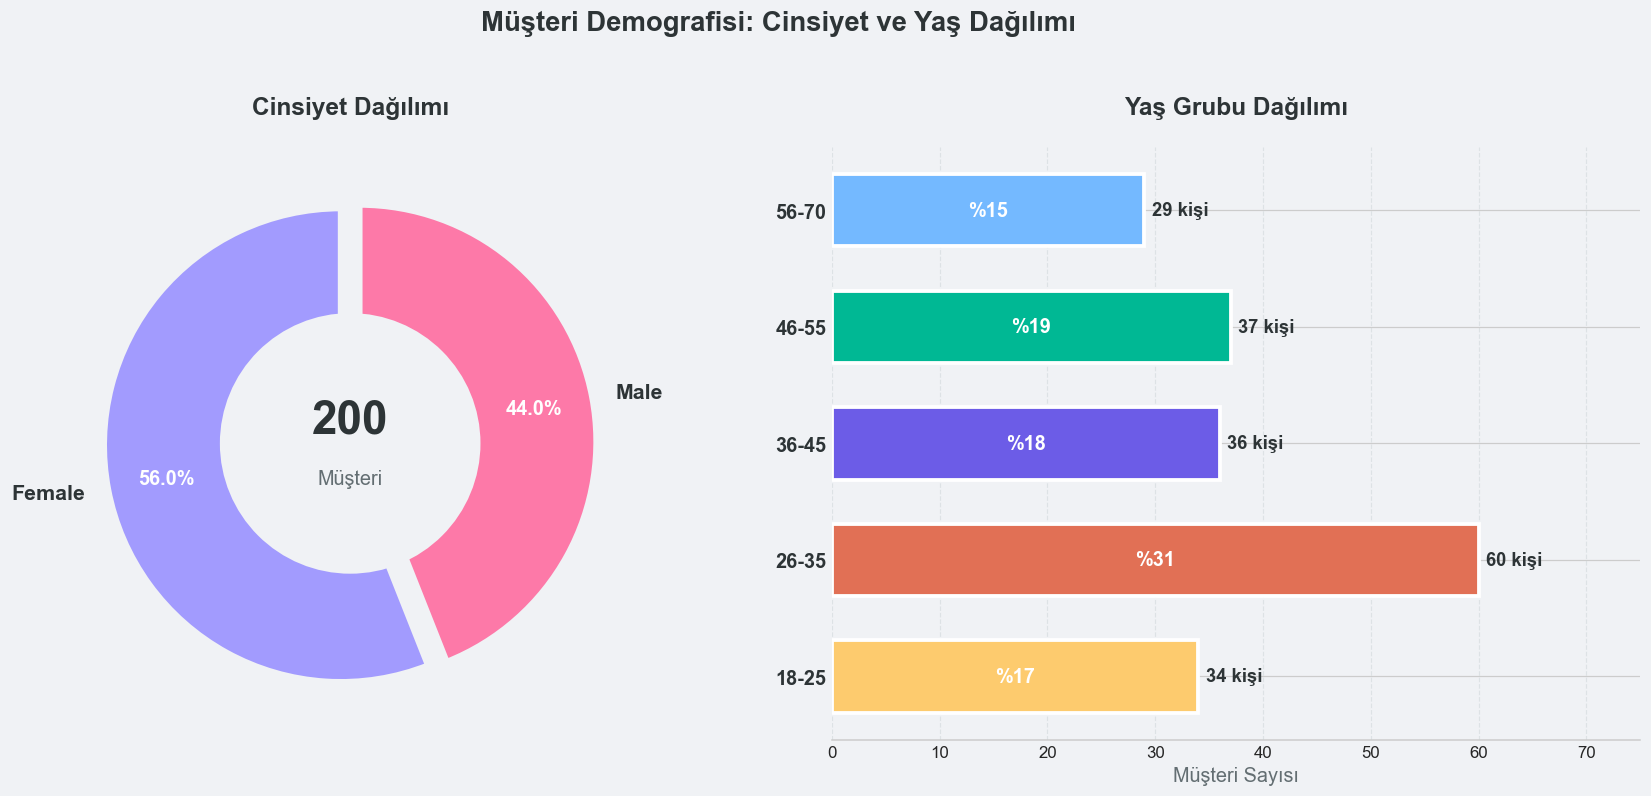

In [21]:
# ============================================================
#  GRAFIK 1: CİNSİYET DAĞILIMI + YAŞ GRUPLARI
#  Matplotlib ile görkemli donut chart + yatay bar chart
# ============================================================

# ── Cinsiyet verileri ───────────────────────────────────────
gender_counts = df['Gender'].value_counts()

# ── Yaş gruplarını oluştur ──────────────────────────────────
age_bins   = [18, 25, 35, 45, 55, 70]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-70']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)
age_group_counts = df['Age_Group'].value_counts().sort_index()

# ── Figure düzeni ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#f0f2f5')

# ── SOL: Donut Chart ────────────────────────────────────────
donut_colors = ['#a29bfe', '#fd79a8']

wedges, texts, autotexts = ax1.pie(
    gender_counts.values,
    labels=gender_counts.index,
    colors=donut_colors,
    explode=(0.04, 0.04),
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'linewidth': 4, 'edgecolor': '#f0f2f5'},
    textprops={'fontsize': 14},
    pctdistance=0.75
)

# Beyaz merkez dairesi → donut etkisi
centre_circle = plt.Circle((0, 0), 0.55, fc='#f0f2f5')
ax1.add_patch(centre_circle)

# Merkeze istatistik yaz
ax1.text(0,  0.10, '200',     ha='center', va='center',
         fontsize=30, fontweight='bold', color='#2d3436')
ax1.text(0, -0.15, 'Müşteri', ha='center', va='center',
         fontsize=13, color='#636e72')

# Etiket stilleri
for t in texts:
    t.set_fontsize(14); t.set_fontweight('bold'); t.set_color('#2d3436')
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold'); at.set_color('white')

ax1.set_title('Cinsiyet Dağılımı', fontsize=16, fontweight='bold', pad=22, color='#2d3436')
ax1.set_facecolor('#f0f2f5')

# ── SAĞ: Yatay Bar Chart — Yaş Grupları ────────────────────
bar_colors_age = ['#fdcb6e', '#e17055', '#6c5ce7', '#00b894', '#74b9ff']
y_pos = range(len(age_group_counts))

bars = ax2.barh(
    y=list(y_pos),
    width=age_group_counts.values,
    color=bar_colors_age,
    height=0.62,
    edgecolor='white',
    linewidth=2.5
)

total = age_group_counts.sum()

for bar, val in zip(bars, age_group_counts.values):
    pct = val / total * 100
    # Barın içine yüzde yaz
    ax2.text(
        bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
        f'%{pct:.0f}', va='center', ha='center',
        fontsize=13, fontweight='bold', color='white'
    )
    # Barın ucuna kişi sayısı yaz
    ax2.text(
        bar.get_width() + 0.7, bar.get_y() + bar.get_height() / 2,
        f'{val} kişi', va='center', ha='left',
        fontsize=12, fontweight='bold', color='#2d3436'
    )

ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(age_group_counts.index.tolist(), fontsize=13, fontweight='bold', color='#2d3436')
ax2.set_xlabel('Müşteri Sayısı', fontsize=13, color='#636e72')
ax2.set_title('Yaş Grubu Dağılımı', fontsize=16, fontweight='bold', pad=22, color='#2d3436')
ax2.set_xlim(0, age_group_counts.max() + 15)
ax2.set_facecolor('#f0f2f5')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(axis='y', length=0)
ax2.grid(axis='x', alpha=0.3, linestyle='--', color='#b2bec3')

plt.suptitle('Müşteri Demografisi: Cinsiyet ve Yaş Dağılımı',
             fontsize=18, fontweight='bold', color='#2d3436', y=1.03)
plt.tight_layout()
plt.show()


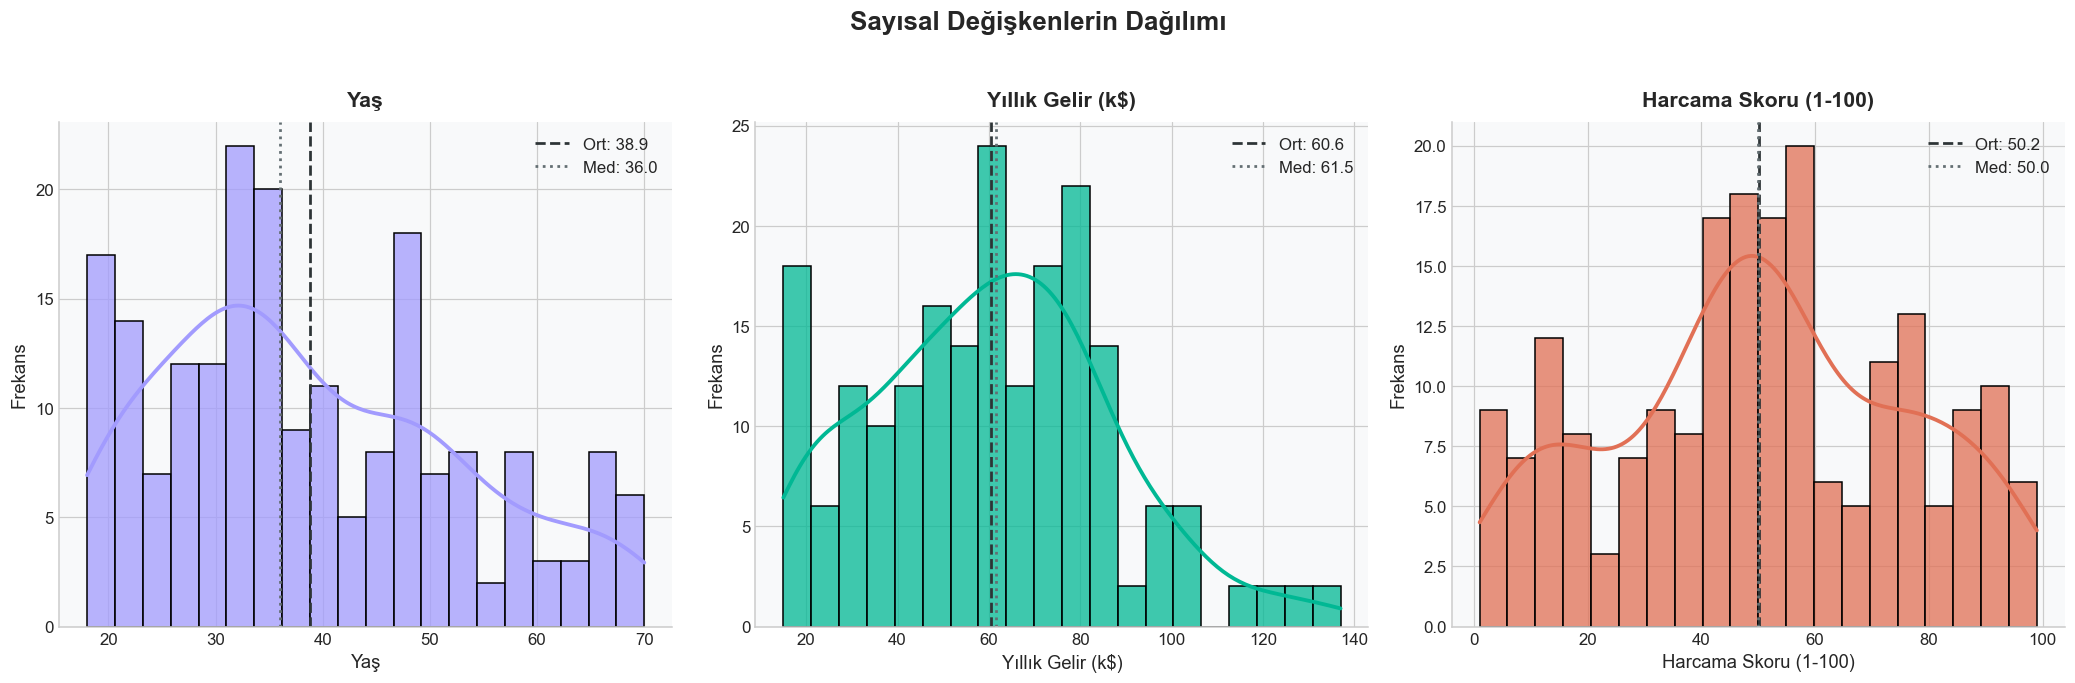

In [22]:
# ============================================================
#  GRAFIK 2: SAYISAL DEĞİŞKENLERİN DAĞILIMI
#  Histogram + KDE çizgisi + ortalama/medyan işaretleri
#  Her sütun için ayrı renk ve bilgi kutusu
# ============================================================

numeric_cols    = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
turkish_labels  = ['Yaş', 'Yıllık Gelir (k$)', 'Harcama Skoru (1-100)']
bar_colors      = ['#a29bfe', '#00b894', '#e17055']
kde_colors      = ['#6c5ce7', '#007a5e', '#c0392b']

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('Sayısal Değişkenlerin Dağılımı', fontsize=17, fontweight='bold', y=1.03)

for i, (col, label, bar_c, kde_c) in enumerate(zip(numeric_cols, turkish_labels, bar_colors, kde_colors)):

    # Histogram + KDE (seaborn histplot daha temiz)
    sns.histplot(
        df[col], bins=20, color=bar_c, alpha=0.75,
        kde=True, ax=axes[i],
        line_kws={'linewidth': 2.5, 'color': kde_c}
    )

    # Ortalama ve medyan çizgileri
    mean_val   = df[col].mean()
    median_val = df[col].median()

    axes[i].axvline(mean_val,   color='#2d3436', linestyle='--', linewidth=1.8,
                    label=f'Ort: {mean_val:.1f}')
    axes[i].axvline(median_val, color='#636e72', linestyle=':',  linewidth=1.8,
                    label=f'Med: {median_val:.1f}')

    axes[i].set_title(label, fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel(label, fontsize=12)
    axes[i].set_ylabel('Frekans', fontsize=12)
    axes[i].legend(fontsize=11)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    # Arka plan açık renk
    axes[i].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()


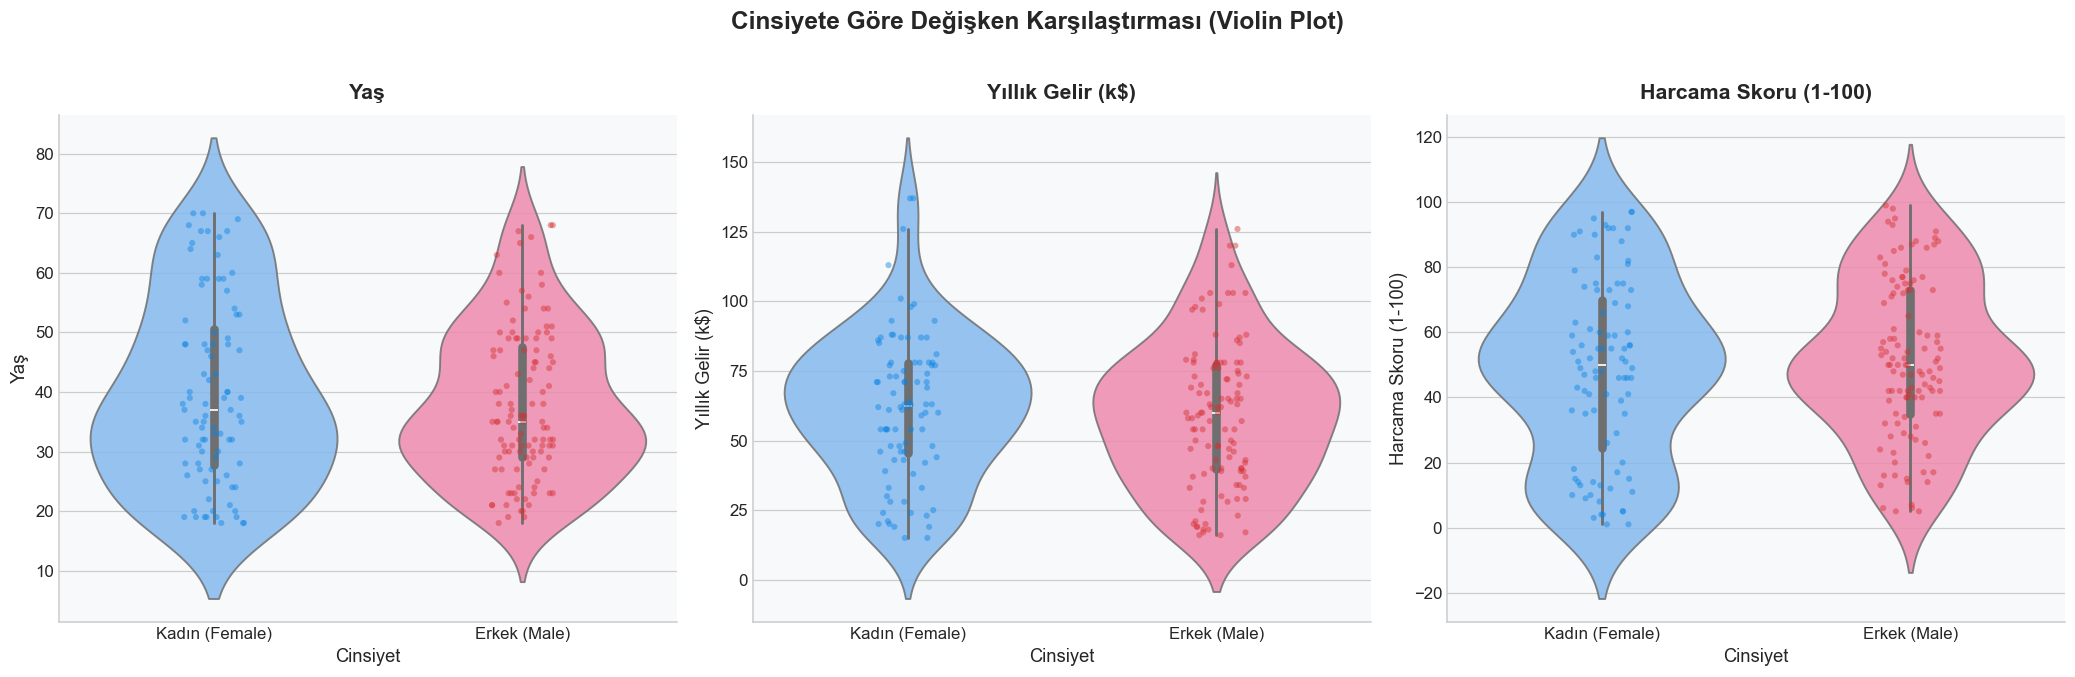

In [23]:
# ============================================================
#  GRAFIK 3: CİNSİYETE GÖRE KEMAN (VİOLİN) + BOXPLOT
#  seaborn violinplot — hem dağılımı hem de boxplot'ı bir arada gösterir
#  Cinsiyet grupları arası karşılaştırma yapılabilir
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('Cinsiyete Göre Değişken Karşılaştırması (Violin Plot)', fontsize=16, fontweight='bold', y=1.02)

numeric_cols   = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
turkish_labels = ['Yaş', 'Yıllık Gelir (k$)', 'Harcama Skoru (1-100)']

for i, (col, label) in enumerate(zip(numeric_cols, turkish_labels)):

    # Violin plot (dağılım şeklini gösterir)
    sns.violinplot(
        data=df, x='Gender', y=col,
        palette={'Female': '#fd79a8', 'Male': '#74b9ff'},
        inner='box',   # içinde boxplot göster
        alpha=0.85,
        ax=axes[i]
    )

    # Strip plot — gerçek veri noktaları
    sns.stripplot(
        data=df, x='Gender', y=col,
        palette={'Female': '#d63031', 'Male': '#0984e3'},
        size=4, alpha=0.45, jitter=True,
        ax=axes[i]
    )

    axes[i].set_title(label, fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('Cinsiyet', fontsize=12)
    axes[i].set_ylabel(label, fontsize=12)
    axes[i].set_xticklabels(['Kadın (Female)', 'Erkek (Male)'], fontsize=11)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()


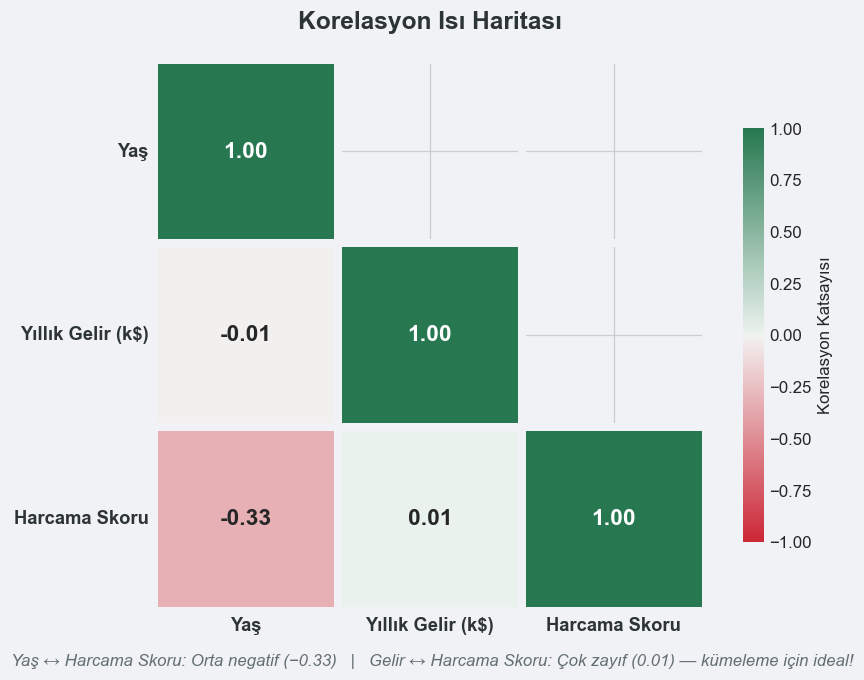

In [24]:
# ============================================================
#  GRAFIK 4: KORELASYON ISI HARİTASI
#  Sayısal değişkenler arasındaki ilişkiyi gösterir
#  Kümeleme öncesi hangi değişkenlerin birlikte hareket ettiğini anlama
# ============================================================

df_numeric = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()
corr_matrix = df_numeric.corr()

# ── Üçgen maske: sadece alt üçgeni göster ──────────────────
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#f0f2f5')
ax.set_facecolor('#f0f2f5')

# Isı haritası
cmap = sns.diverging_palette(10, 145, s=85, l=45, as_cmap=True)
sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=4,
    linecolor='#f0f2f5',
    annot_kws={'size': 15, 'weight': 'bold'},
    cbar_kws={'shrink': 0.75, 'label': 'Korelasyon Katsayısı'}
)

# Özel etiketler
labels = ['Yaş', 'Yıllık Gelir (k$)', 'Harcama Skoru']
ax.set_xticklabels(labels, fontsize=12, fontweight='bold', color='#2d3436')
ax.set_yticklabels(labels, fontsize=12, fontweight='bold', color='#2d3436', rotation=0)
ax.set_title('Korelasyon Isı Haritası', fontsize=16, fontweight='bold',
             pad=20, color='#2d3436')

# Korelasyon yorumlarını alt kısma ekle
yorum = (
    "Yaş ↔ Harcama Skoru: Orta negatif (−0.33)   |   "
    "Gelir ↔ Harcama Skoru: Çok zayıf (0.01) — kümeleme için ideal!"
)
fig.text(0.5, -0.02, yorum, ha='center', fontsize=11,
         color='#636e72', fontstyle='italic')

plt.tight_layout()
plt.show()


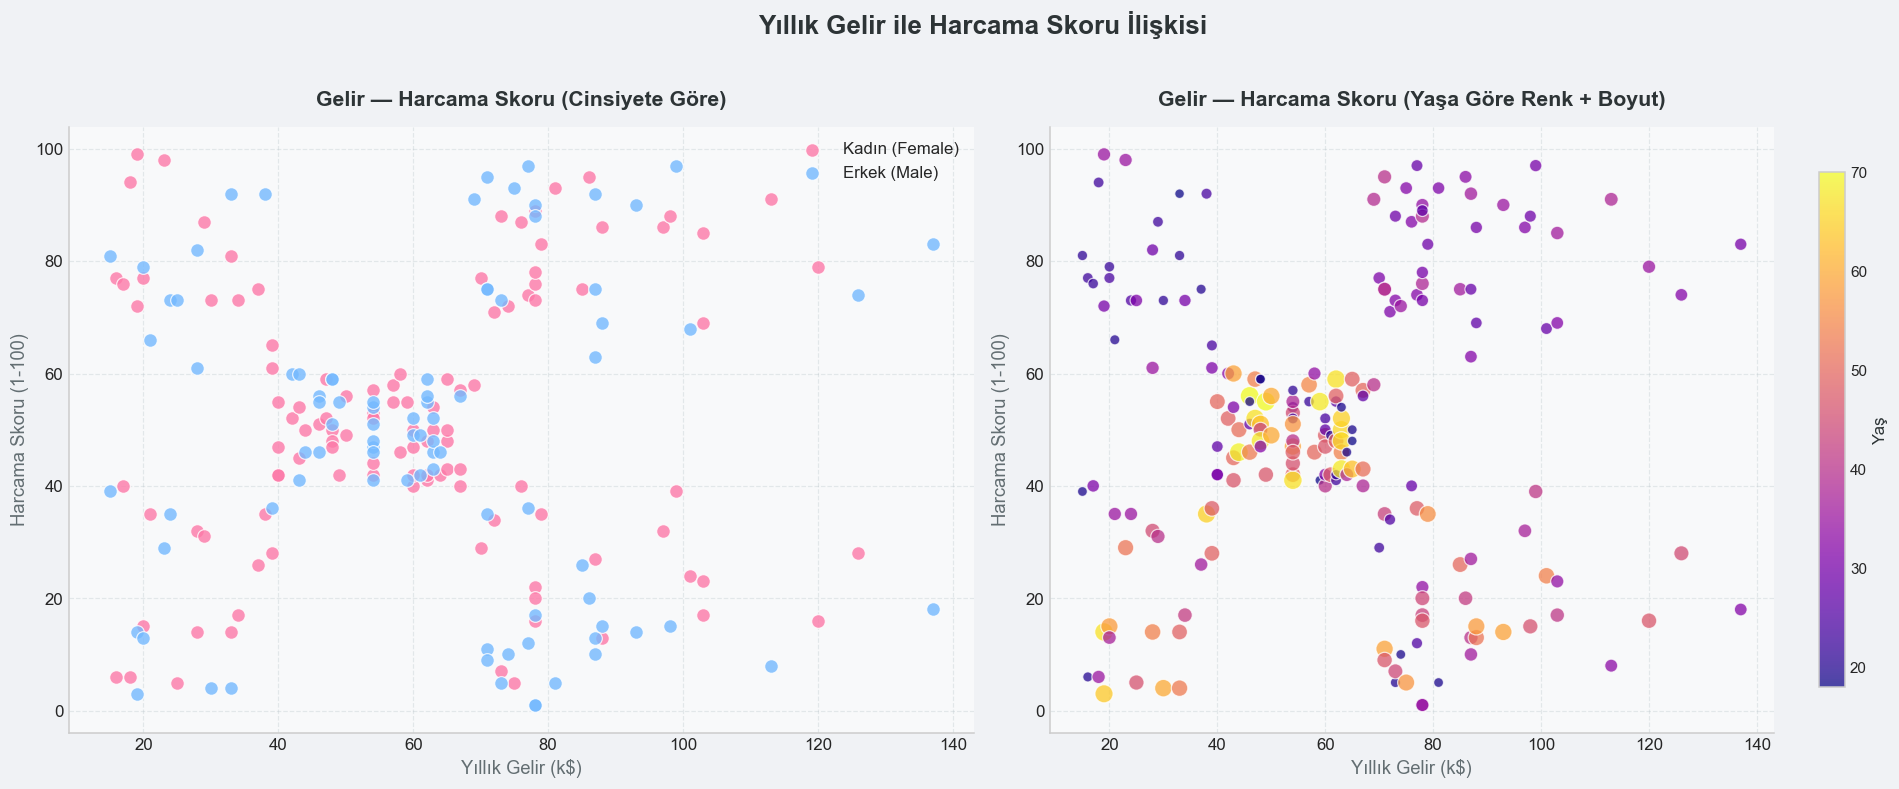

Gözlem: Gelir–Harcama düzleminde 5 belirgin küme yapısı görülüyor.
Bölüm 4'te bu yapıyı dendrogram ile doğrulayacağız.


In [25]:
# ============================================================
#  GRAFIK 5: GELİR vs HARCAMA SKORU — 2B SCATTER
#  Cinsiyete göre renklendirilmiş + yaşa göre boyutlandırılmış
#  Kümeleme öncesindeki doğal yapıyı gözlemle
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#f0f2f5')

# ── Sol: Cinsiyete göre renkli scatter ──────────────────────
colors_gender = {'Male': '#74b9ff', 'Female': '#fd79a8'}

for gender, grp in df.groupby('Gender'):
    axes[0].scatter(
        grp['Annual Income (k$)'],
        grp['Spending Score (1-100)'],
        label='Erkek (Male)' if gender == 'Male' else 'Kadın (Female)',
        color=colors_gender[gender],
        s=80, alpha=0.80, edgecolors='white', linewidths=0.8
    )

axes[0].set_title('Gelir — Harcama Skoru (Cinsiyete Göre)',
                  fontsize=14, fontweight='bold', pad=14, color='#2d3436')
axes[0].set_xlabel('Yıllık Gelir (k$)', fontsize=12, color='#636e72')
axes[0].set_ylabel('Harcama Skoru (1-100)', fontsize=12, color='#636e72')
axes[0].legend(fontsize=11, framealpha=0.8)
axes[0].set_facecolor('#f8f9fa')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(alpha=0.3, linestyle='--', color='#b2bec3')

# ── Sağ: Yaşa göre boyutlandırılmış bubble chart ───────────
scatter = axes[1].scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Age'],
    cmap='plasma',
    s=df['Age'] * 2.2,          # yaş → nokta boyutu
    alpha=0.75,
    edgecolors='white',
    linewidths=0.8
)

# Renk çubuğu (colorbar)
cbar = plt.colorbar(scatter, ax=axes[1], shrink=0.85)
cbar.set_label('Yaş', fontsize=11, color='#2d3436')
cbar.ax.tick_params(labelsize=10)

axes[1].set_title('Gelir — Harcama Skoru (Yaşa Göre Renk + Boyut)',
                  fontsize=14, fontweight='bold', pad=14, color='#2d3436')
axes[1].set_xlabel('Yıllık Gelir (k$)', fontsize=12, color='#636e72')
axes[1].set_ylabel('Harcama Skoru (1-100)', fontsize=12, color='#636e72')
axes[1].set_facecolor('#f8f9fa')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(alpha=0.3, linestyle='--', color='#b2bec3')

# Genel başlık
plt.suptitle('Yıllık Gelir ile Harcama Skoru İlişkisi',
             fontsize=17, fontweight='bold', color='#2d3436', y=1.02)
plt.tight_layout()
plt.show()

print("Gözlem: Gelir–Harcama düzleminde 5 belirgin küme yapısı görülüyor.")
print("Bölüm 4'te bu yapıyı dendrogram ile doğrulayacağız.")


In [26]:
from IPython.display import display, HTML

# Gerçek değerleri hesapla
avg_age      = df['Age'].mean()
avg_income   = df['Annual Income (k$)'].mean()
avg_spending = df['Spending Score (1-100)'].mean()
female_pct   = (df['Gender'] == 'Female').mean() * 100
male_pct     = 100 - female_pct
age_corr     = df['Age'].corr(df['Spending Score (1-100)'])
inc_corr     = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])

display(HTML(f"""
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%);
            border-radius: 18px; padding: 30px 34px; margin-top: 18px;
            box-shadow: 0 10px 35px rgba(42,82,152,0.35);">

  <div style="display: flex; align-items: center; gap: 14px; margin-bottom: 22px;">
    <span style="font-size: 2em;">📋</span>
    <div>
      <h3 style="color: white; margin: 0; font-size: 1.3em; font-weight: 800;">EDA Özet: Ne Öğrendik?</h3>
      <p style="color: rgba(255,255,255,0.65); margin: 4px 0 0 0; font-size: 0.88em;">
        Bölüm 3 tamamlandı — Verinin genel yapısı anlaşıldı.
      </p>
    </div>
  </div>

  <div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 12px; margin-bottom: 18px;">
    <div style="background: rgba(255,255,255,0.1); border-radius: 12px; padding: 16px 12px; text-align: center; border: 1px solid rgba(162,155,254,0.4);">
      <p style="color: #a29bfe; font-size: 0.78em; margin: 0 0 6px 0; text-transform: uppercase; letter-spacing: 1px;">Ortalama Yaş</p>
      <p style="color: white; font-size: 1.8em; font-weight: 800; margin: 0;">{avg_age:.0f}</p>
      <p style="color: rgba(255,255,255,0.6); font-size: 0.75em; margin: 4px 0 0 0;">Kadın: %{female_pct:.0f} · Erkek: %{male_pct:.0f}</p>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 12px; padding: 16px 12px; text-align: center; border: 1px solid rgba(85,239,196,0.4);">
      <p style="color: #55efc4; font-size: 0.78em; margin: 0 0 6px 0; text-transform: uppercase; letter-spacing: 1px;">Ort. Gelir</p>
      <p style="color: white; font-size: 1.8em; font-weight: 800; margin: 0;">{avg_income:.0f}k$</p>
      <p style="color: rgba(255,255,255,0.6); font-size: 0.75em; margin: 4px 0 0 0;">Yıllık ortalama</p>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 12px; padding: 16px 12px; text-align: center; border: 1px solid rgba(253,203,110,0.4);">
      <p style="color: #fdcb6e; font-size: 0.78em; margin: 0 0 6px 0; text-transform: uppercase; letter-spacing: 1px;">Ort. Harcama Skoru</p>
      <p style="color: white; font-size: 1.8em; font-weight: 800; margin: 0;">{avg_spending:.0f}</p>
      <p style="color: rgba(255,255,255,0.6); font-size: 0.75em; margin: 4px 0 0 0;">100 üzerinden</p>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 12px; padding: 16px 12px; text-align: center; border: 1px solid rgba(253,121,168,0.4);">
      <p style="color: #fd79a8; font-size: 0.78em; margin: 0 0 6px 0; text-transform: uppercase; letter-spacing: 1px;">Eksik Değer</p>
      <p style="color: white; font-size: 1.8em; font-weight: 800; margin: 0;">0</p>
      <p style="color: rgba(255,255,255,0.6); font-size: 0.75em; margin: 4px 0 0 0;">Veri temiz!</p>
    </div>
  </div>

  <div style="background: rgba(255,255,255,0.07); border-radius: 12px; padding: 18px 20px; border-left: 4px solid #fdcb6e;">
    <p style="color: #fdcb6e; font-weight: 800; font-size: 0.95em; margin: 0 0 10px 0;">Kümeleme için kritik gözlemler:</p>
    <ul style="color: rgba(255,255,255,0.85); font-size: 0.9em; margin: 0; padding-left: 20px; line-height: 2;">
      <li><strong>Gelir–Harcama scatter</strong>'da 5 belirgin küme görülüyor — mükemmel kümeleme senaryosu!</li>
      <li>Gelir ↔ Harcama korelasyonu: <strong>{inc_corr:.2f}</strong> (neredeyse sıfır) — bağımsız iki değişken, iyi ayrışma sağlar.</li>
      <li>Yaş ↔ Harcama korelasyonu: <strong>{age_corr:.2f}</strong> — yaşlı müşteriler daha az harcama eğiliminde.</li>
      <li>Veri temiz: eksik değer yok, ölçekleme gerekiyor (bir sonraki bölüm).</li>
    </ul>
  </div>

</div>
"""))


In [27]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(90deg, #6c5ce7 0%, #fd79a8 100%); padding: 22px 32px; border-radius: 14px; margin-top: 28px; box-shadow: 0 8px 25px rgba(108,92,231,0.35);">
  <h2 style="color: white; margin: 0; font-size: 1.55em; font-weight: 800; letter-spacing: 0.5px;">
    BÖLÜM 4 &nbsp;·&nbsp; Veri Ön İşleme
  </h2>
  <p style="color: rgba(255,255,255,0.88); margin: 7px 0 0 0; font-size: 0.95em;">
    Label Encoding &nbsp;·&nbsp; Gereksiz Sütun Silme &nbsp;·&nbsp; MinMax Normalizasyon &nbsp;·&nbsp; Özellik Setleri
  </p>
</div>
"""))


In [28]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: white; border-radius: 16px; padding: 28px 32px; border: 1.5px solid #dee2e6;
            margin-top: 14px; box-shadow: 0 4px 18px rgba(0,0,0,0.06);">

  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 20px;">
    <span style="font-size: 2em;">⚙️</span>
    <h3 style="margin: 0; color: #2d3436; font-size: 1.25em; font-weight: 800;">
      Neden Ön İşleme Gereklidir?
    </h3>
  </div>

  <p style="color: #636e72; font-size: 0.93em; line-height: 1.75; margin: 0 0 18px 0;">
    Hiyerarşik kümeleme (ve K-Means) <strong>mesafe hesabına</strong> dayanır.
    Ham veriyi doğrudan modele vermek <strong>yanlış ve yanıltıcı sonuçlar</strong> doğurur.
    Üç kritik adım gereklidir:
  </p>

  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 14px;">

    <div style="background: linear-gradient(145deg, #e8eaf6, #c5cae9); border-radius: 14px; padding: 20px 16px; border-top: 4px solid #5c6bc0;">
      <div style="text-align: center; margin-bottom: 12px;">
        <span style="background: #5c6bc0; color: white; font-size: 0.75em; padding: 4px 12px;
               border-radius: 20px; font-weight: 700;">ADIM 1</span>
        <h4 style="color: #283593; margin: 10px 0 6px 0; font-size: 1em;">Label Encoding</h4>
      </div>
      <p style="color: #1a237e; font-size: 0.84em; line-height: 1.65; margin: 0 0 10px 0;">
        Algoritmalar <strong>yalnızca sayı</strong> işleyebilir.
        <code style="background: #c5cae9; padding: 1px 5px; border-radius: 4px;">Gender</code>
        sütunundaki <em>Female / Male</em> metinleri <strong>0 / 1</strong>'e dönüştürülür.
      </p>
      <div style="background: rgba(255,255,255,0.7); border-radius: 8px; padding: 8px 10px; text-align: center; font-size: 0.85em; color: #283593;">
        Female &nbsp;→&nbsp; <strong>0</strong><br>
        Male &nbsp;→&nbsp; <strong>1</strong>
      </div>
    </div>

    <div style="background: linear-gradient(145deg, #fce4ec, #f8bbd0); border-radius: 14px; padding: 20px 16px; border-top: 4px solid #e91e63;">
      <div style="text-align: center; margin-bottom: 12px;">
        <span style="background: #e91e63; color: white; font-size: 0.75em; padding: 4px 12px;
               border-radius: 20px; font-weight: 700;">ADIM 2</span>
        <h4 style="color: #880e4f; margin: 10px 0 6px 0; font-size: 1em;">Gereksiz Sütun Sil</h4>
      </div>
      <p style="color: #880e4f; font-size: 0.84em; line-height: 1.65; margin: 0 0 10px 0;">
        <code style="background: #f8bbd0; padding: 1px 5px; border-radius: 4px;">CustomerID</code>
        sadece bir sıra numarasıdır — <strong>hiçbir anlamlı bilgi</strong> taşımaz.
        Modele dahil edilirse mesafe hesabını bozar.
      </p>
      <div style="background: rgba(255,255,255,0.7); border-radius: 8px; padding: 8px 10px; text-align: center; font-size: 0.85em; color: #880e4f;">
        <strong>CustomerID</strong> &nbsp;→&nbsp; ❌ Çıkar<br>
        <strong>Age_Group</strong> &nbsp;→&nbsp; ❌ Çıkar
      </div>
    </div>

    <div style="background: linear-gradient(145deg, #e8f5e9, #c8e6c9); border-radius: 14px; padding: 20px 16px; border-top: 4px solid #388e3c;">
      <div style="text-align: center; margin-bottom: 12px;">
        <span style="background: #388e3c; color: white; font-size: 0.75em; padding: 4px 12px;
               border-radius: 20px; font-weight: 700;">ADIM 3</span>
        <h4 style="color: #1b5e20; margin: 10px 0 6px 0; font-size: 1em;">MinMax Ölçekleme</h4>
      </div>
      <p style="color: #1b5e20; font-size: 0.84em; line-height: 1.65; margin: 0 0 10px 0;">
        Gelir <strong>15–137k$</strong>, Yaş <strong>18–70</strong>: farklı birimler.
        Büyük değerli sütun mesafeye <em>hakimdir</em>.
        Tüm değişkenler <strong>[0, 1]</strong> aralığına çekilir.
      </p>
      <div style="background: rgba(255,255,255,0.7); border-radius: 8px; padding: 8px 10px; text-align: center;">
        <span style="font-size: 0.9em; color: #1b5e20; font-weight: 600;">
          x' = (x − x<sub>min</sub>) / (x<sub>max</sub> − x<sub>min</sub>)
        </span>
      </div>
    </div>

  </div>

</div>
"""))


In [29]:
# ============================================================
#  ADIM 1 & 2: LABEL ENCODING + GEREKSIZ SÜTUNLARI KALDIR
#  Orijinal df'e dokunmuyoruz — df_model kopyası üzerinde çalış
# ============================================================

df_model = df.copy()   # ham veriyi korumak için kopya

# ── Label Encoding: Gender → 0/1 ─────────────────────────
le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])
# Female=0, Male=1 (alfabetik sıra)

# ── Gereksiz sütunları kaldır ──────────────────────────────
drop_cols = ['CustomerID']
if 'Age_Group' in df_model.columns:
    drop_cols.append('Age_Group')         # EDA için oluşturmuştuk

df_model = df_model.drop(columns=drop_cols)

# ── Sonucu göster ──────────────────────────────────────────
print("=" * 58)
print("  ADIM 1 & 2 TAMAMLANDI")
print("=" * 58)
print(f"\n  Gender encoding: Female → {le.classes_[0]} = 0,  Male → {le.classes_[1]} = 1")
print(f"  Kaldırılan sütunlar: {drop_cols}")
print(f"  df_model boyutu: {df_model.shape[0]} satır × {df_model.shape[1]} sütun")
print(f"  Kalan sütunlar: {list(df_model.columns)}")
print()

display(df_model.head(6).style
    .background_gradient(cmap='Purples', subset=['Gender'])
    .background_gradient(cmap='Blues',   subset=['Annual Income (k$)'])
    .background_gradient(cmap='Oranges', subset=['Spending Score (1-100)'])
    .set_caption("df_model — İlk 6 Satır (Label Encoding Sonrası)")
    .set_properties(**{'font-size': '12px', 'border': '1px solid #dee2e6', 'text-align': 'center'})
)


  ADIM 1 & 2 TAMAMLANDI

  Gender encoding: Female → Female = 0,  Male → Male = 1
  Kaldırılan sütunlar: ['CustomerID', 'Age_Group']
  df_model boyutu: 200 satır × 4 sütun
  Kalan sütunlar: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']



,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
5,0,22,17,76


In [30]:
# ============================================================
#  ADIM 3: MINMAX NORMALIZASYON
#  Tüm sayısal sütunları [0, 1] aralığına çek
#  Formül: x' = (x - x_min) / (x_max - x_min)
# ============================================================

scaler     = MinMaxScaler()
scale_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

df_scaled                = df_model.copy()
df_scaled[scale_cols]    = scaler.fit_transform(df_model[scale_cols])

# ── Özet rapor ─────────────────────────────────────────────
print("=" * 65)
print("  ADIM 3: MINMAXSCALİNG TAMAMLANDI")
print("=" * 65)
print(f"\n  {'Sütun':<38} {'Önce (min–max)':<18} {'Sonra (min–max)'}")
print("  " + "-" * 62)
for col in scale_cols:
    o_min = df_model[col].min()
    o_max = df_model[col].max()
    s_min = df_scaled[col].min()
    s_max = df_scaled[col].max()
    print(f"  {col:<38} [{o_min:.1f} – {o_max:.1f}]{'':<8} [{s_min:.2f} – {s_max:.2f}]")
print()

display(df_scaled.head(6).style
    .background_gradient(cmap='Greens', subset=scale_cols)
    .format({col: '{:.4f}' for col in scale_cols})
    .set_caption("df_scaled — İlk 6 Satır (MinMax Normalizasyon Sonrası)")
    .set_properties(**{'font-size': '12px', 'border': '1px solid #dee2e6', 'text-align': 'center'})
)


  ADIM 3: MINMAXSCALİNG TAMAMLANDI

  Sütun                                  Önce (min–max)     Sonra (min–max)
  --------------------------------------------------------------
  Age                                    [18.0 – 70.0]         [0.00 – 1.00]
  Annual Income (k$)                     [15.0 – 137.0]         [0.00 – 1.00]
  Spending Score (1-100)                 [1.0 – 99.0]         [0.00 – 1.00]



,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0.0192,0.0000,0.3878
1,1,0.0577,0.0000,0.8163
2,0,0.0385,0.0082,0.0510
3,0,0.0962,0.0082,0.7755
4,0,0.2500,0.0164,0.3980
5,0,0.0769,0.0164,0.7653


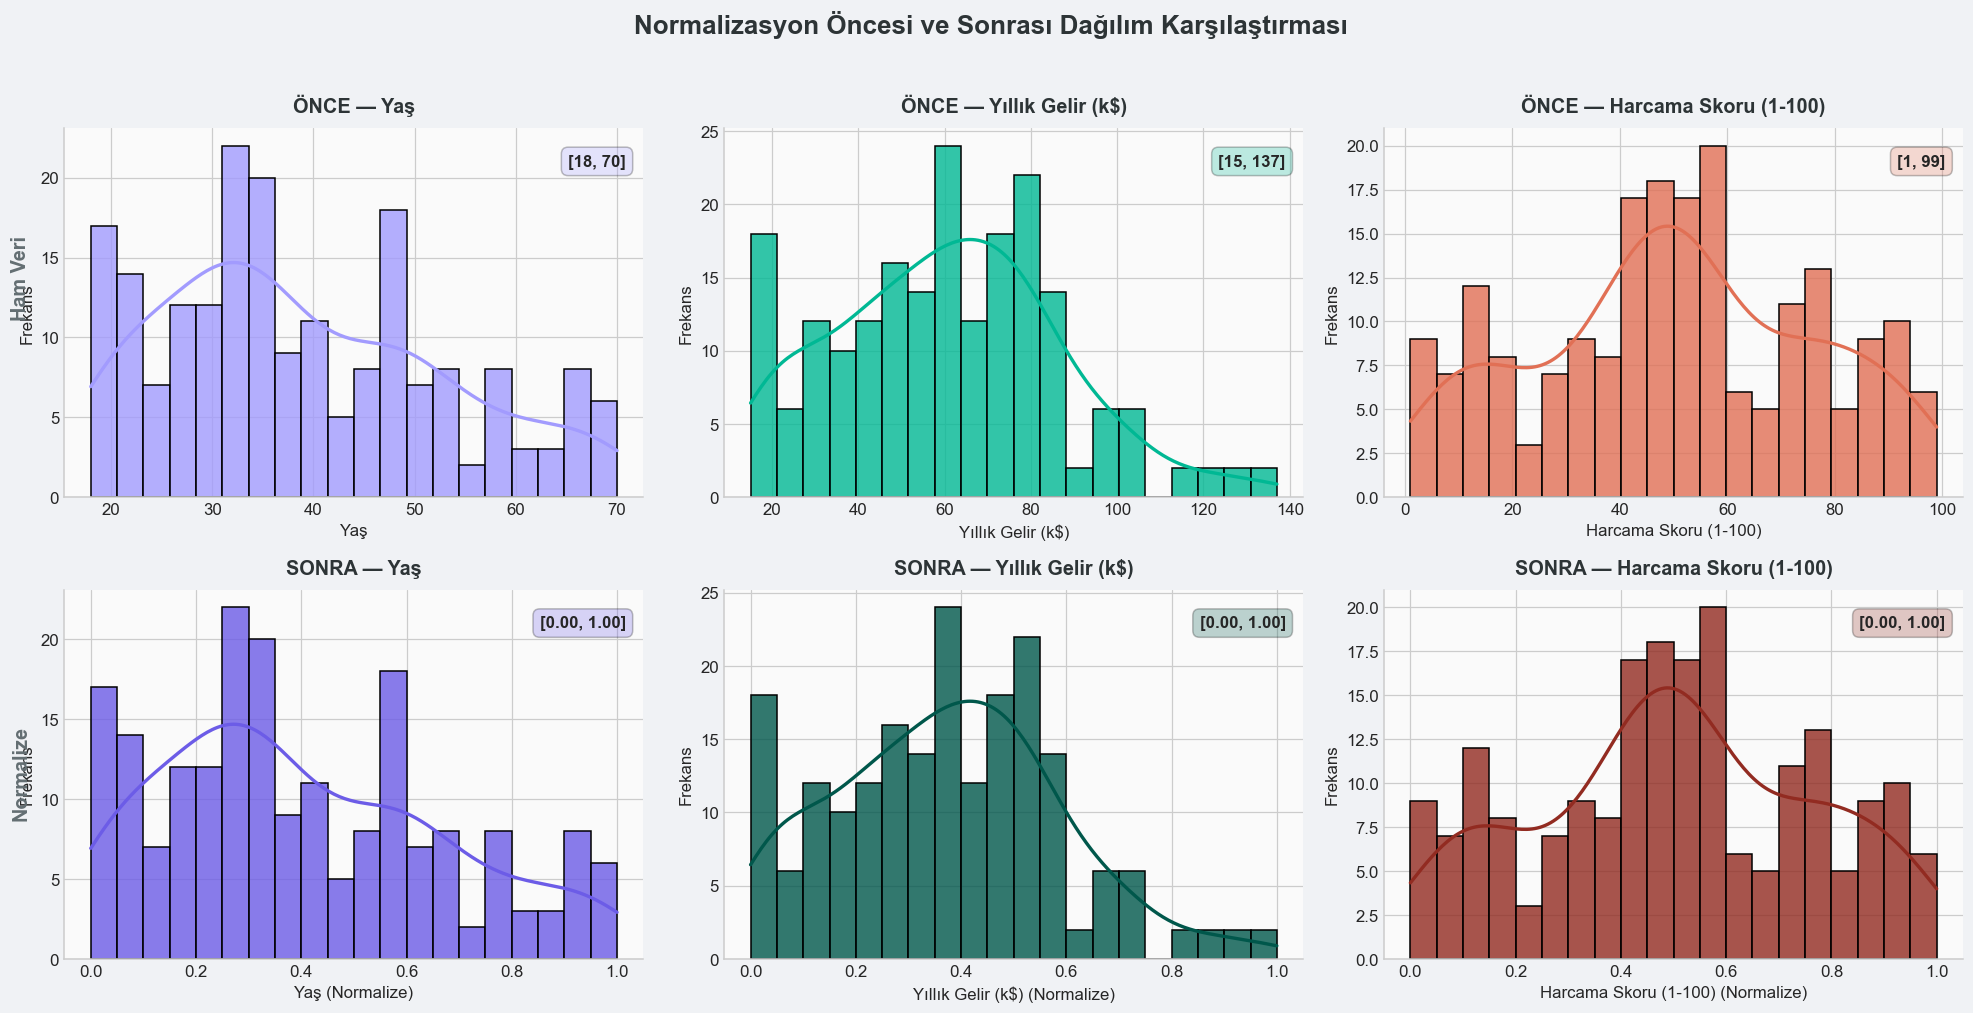

Gözlem: Dağılım şekli tamamen korundu — sadece ölçek değişti.
Tüm sütunlar artık [0.0, 1.0] aralığında. Mesafe hesabı adil olacak.


In [31]:
# ============================================================
#  GÖRSELLEŞTIRME: ÖNCESİ vs SONRASI KARŞILAŞTIRMA
#  Her değişken için üst sıra = ham veri, alt sıra = normalize
#  Dağılım şekli korunur ama ölçek [0,1]'e çekilir
# ============================================================

scale_cols     = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
turkish_labels = ['Yaş', 'Yıllık Gelir (k$)', 'Harcama Skoru (1-100)']
colors_before  = ['#a29bfe', '#00b894', '#e17055']
colors_after   = ['#6c5ce7', '#00574b', '#922b21']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.patch.set_facecolor('#f0f2f5')
fig.suptitle('Normalizasyon Öncesi ve Sonrası Dağılım Karşılaştırması',
             fontsize=17, fontweight='bold', color='#2d3436', y=1.02)

for i, (col, label, c_b, c_a) in enumerate(zip(scale_cols, turkish_labels, colors_before, colors_after)):

    # ── ÜST SIRA: Ham veri ──────────────────────────────────
    sns.histplot(df_model[col], bins=20, color=c_b, alpha=0.80,
                 kde=True, ax=axes[0, i],
                 line_kws={'linewidth': 2.2, 'color': c_a})
    axes[0, i].set_title(f'ÖNCE — {label}', fontsize=13, fontweight='bold',
                          color='#2d3436', pad=10)
    axes[0, i].set_xlabel(label, fontsize=11)
    axes[0, i].set_ylabel('Frekans', fontsize=11)
    axes[0, i].set_facecolor('#fafafa')
    axes[0, i].spines['top'].set_visible(False)
    axes[0, i].spines['right'].set_visible(False)
    # Aralık etiketi
    rng = f"[{df_model[col].min():.0f}, {df_model[col].max():.0f}]"
    axes[0, i].text(0.97, 0.93, rng, transform=axes[0, i].transAxes,
                    ha='right', va='top', fontsize=11, fontweight='bold',
                    bbox=dict(facecolor=c_b, alpha=0.25, boxstyle='round,pad=0.4'))

    # ── ALT SIRA: Normalize veri ────────────────────────────
    sns.histplot(df_scaled[col], bins=20, color=c_a, alpha=0.80,
                 kde=True, ax=axes[1, i],
                 line_kws={'linewidth': 2.2, 'color': c_b})
    axes[1, i].set_title(f'SONRA — {label}', fontsize=13, fontweight='bold',
                          color='#2d3436', pad=10)
    axes[1, i].set_xlabel(f'{label} (Normalize)', fontsize=11)
    axes[1, i].set_ylabel('Frekans', fontsize=11)
    axes[1, i].set_facecolor('#fafafa')
    axes[1, i].set_xlim(-0.05, 1.05)
    axes[1, i].spines['top'].set_visible(False)
    axes[1, i].spines['right'].set_visible(False)
    axes[1, i].text(0.97, 0.93, '[0.00, 1.00]', transform=axes[1, i].transAxes,
                    ha='right', va='top', fontsize=11, fontweight='bold',
                    bbox=dict(facecolor=c_a, alpha=0.25, boxstyle='round,pad=0.4'))

# Satır etiketleri (sol kenar)
for row_idx, row_label in enumerate(['Ham Veri', 'Normalize']):
    fig.text(0.005, 0.75 - row_idx * 0.5, row_label,
             va='center', ha='left', fontsize=13, fontweight='bold',
             color='#636e72', rotation=90)

plt.tight_layout()
plt.show()

print("Gözlem: Dağılım şekli tamamen korundu — sadece ölçek değişti.")
print("Tüm sütunlar artık [0.0, 1.0] aralığında. Mesafe hesabı adil olacak.")


In [33]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding: 22px 32px; border-radius: 14px; margin-top: 28px; box-shadow: 0 8px 25px rgba(15,52,96,0.45);">
  <h2 style="color: white; margin: 0; font-size: 1.55em; font-weight: 800; letter-spacing: 0.5px;">
    BÖLÜM 5 &nbsp;·&nbsp; Dendrogram &amp; Optimal Küme Sayısı
  </h2>
  <p style="color: rgba(255,255,255,0.80); margin: 7px 0 0 0; font-size: 0.95em;">
    Linkage yöntemleri karşılaştırması &nbsp;·&nbsp; Dendrogram okuma &nbsp;·&nbsp; Kesim noktası seçimi
  </p>
</div>
"""))


In [34]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: white; border-radius: 16px; padding: 28px 32px; border: 1.5px solid #dee2e6;
            margin-top: 14px; box-shadow: 0 4px 18px rgba(0,0,0,0.06);">

  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 18px;">
    <span style="font-size: 2.2em;">🌳</span>
    <h3 style="margin: 0; color: #2d3436; font-size: 1.25em; font-weight: 800;">Dendrogram Nasıl Okunur?</h3>
  </div>

  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 18px;">

    <div>
      <p style="color: #636e72; font-size: 0.93em; line-height: 1.75; margin: 0 0 14px 0;">
        Dendrogram, hiyerarşik kümelemenin <strong>adım adım kayıt defteri</strong>dir.
        Her dal birleşme olayını gösterir.
      </p>
      <div style="display: flex; flex-direction: column; gap: 8px;">
        <div style="background: #e8f5e9; border-radius: 8px; padding: 10px 14px; border-left: 3px solid #4caf50;">
          <strong style="color: #2e7d32; font-size: 0.88em;">Dikey eksen (Y-ekseni)</strong>
          <p style="color: #424242; font-size: 0.83em; margin: 4px 0 0 0;">Birleşme <strong>maliyetini</strong> (mesafesini) gösterir. Yukarı çıktıkça maliyet artar.</p>
        </div>
        <div style="background: #e3f2fd; border-radius: 8px; padding: 10px 14px; border-left: 3px solid #1976d2;">
          <strong style="color: #1565c0; font-size: 0.88em;">Yatay Kesim Çizgisi</strong>
          <p style="color: #424242; font-size: 0.83em; margin: 4px 0 0 0;">Çizgiyle kaç dal kesilirse, o kadar <strong>küme</strong> elde edilir.</p>
        </div>
        <div style="background: #fff3e0; border-radius: 8px; padding: 10px 14px; border-left: 3px solid #ff9800;">
          <strong style="color: #e65100; font-size: 0.88em;">En Uzun Dikey Dal = Optimal Küme</strong>
          <p style="color: #424242; font-size: 0.83em; margin: 4px 0 0 0;">Dal boyu, iki kümenin ne kadar <strong>farklı</strong> olduğunu gösterir. En uzun dalsız bölge = en iyi kesim.</p>
        </div>
      </div>
    </div>

    <div style="background: #f8f9fa; border-radius: 12px; padding: 20px; border: 1px dashed #adb5bd;">
      <p style="color: #495057; font-size: 0.9em; font-weight: 700; margin: 0 0 12px 0;">Kesim Sayısı → Küme Sayısı</p>
      <div style="display: flex; flex-direction: column; gap: 8px;">
        <div style="display: flex; align-items: center; gap: 10px;">
          <div style="background: #6c5ce7; color: white; border-radius: 6px; padding: 4px 12px; font-size: 0.85em; font-weight: 700; min-width: 80px; text-align: center;">1 kesim</div>
          <span style="color: #495057; font-size: 0.88em;">→ 2 küme</span>
        </div>
        <div style="display: flex; align-items: center; gap: 10px;">
          <div style="background: #00b894; color: white; border-radius: 6px; padding: 4px 12px; font-size: 0.85em; font-weight: 700; min-width: 80px; text-align: center;">2 kesim</div>
          <span style="color: #495057; font-size: 0.88em;">→ 3 küme</span>
        </div>
        <div style="display: flex; align-items: center; gap: 10px;">
          <div style="background: #e17055; color: white; border-radius: 6px; padding: 4px 12px; font-size: 0.85em; font-weight: 700; min-width: 80px; text-align: center;">4 kesim</div>
          <span style="color: #495057; font-size: 0.88em;">→ <strong>5 küme</strong> (bizim verimiz için ideal!)</span>
        </div>
      </div>
      <div style="background: #2d3436; border-radius: 8px; padding: 10px 14px; margin-top: 14px;">
        <p style="color: #fdcb6e; font-size: 0.82em; margin: 0; font-weight: 700;">
          Kural: Çizgi kaç dikey dal keserse = o kadar küme
        </p>
      </div>
    </div>

  </div>

</div>
"""))


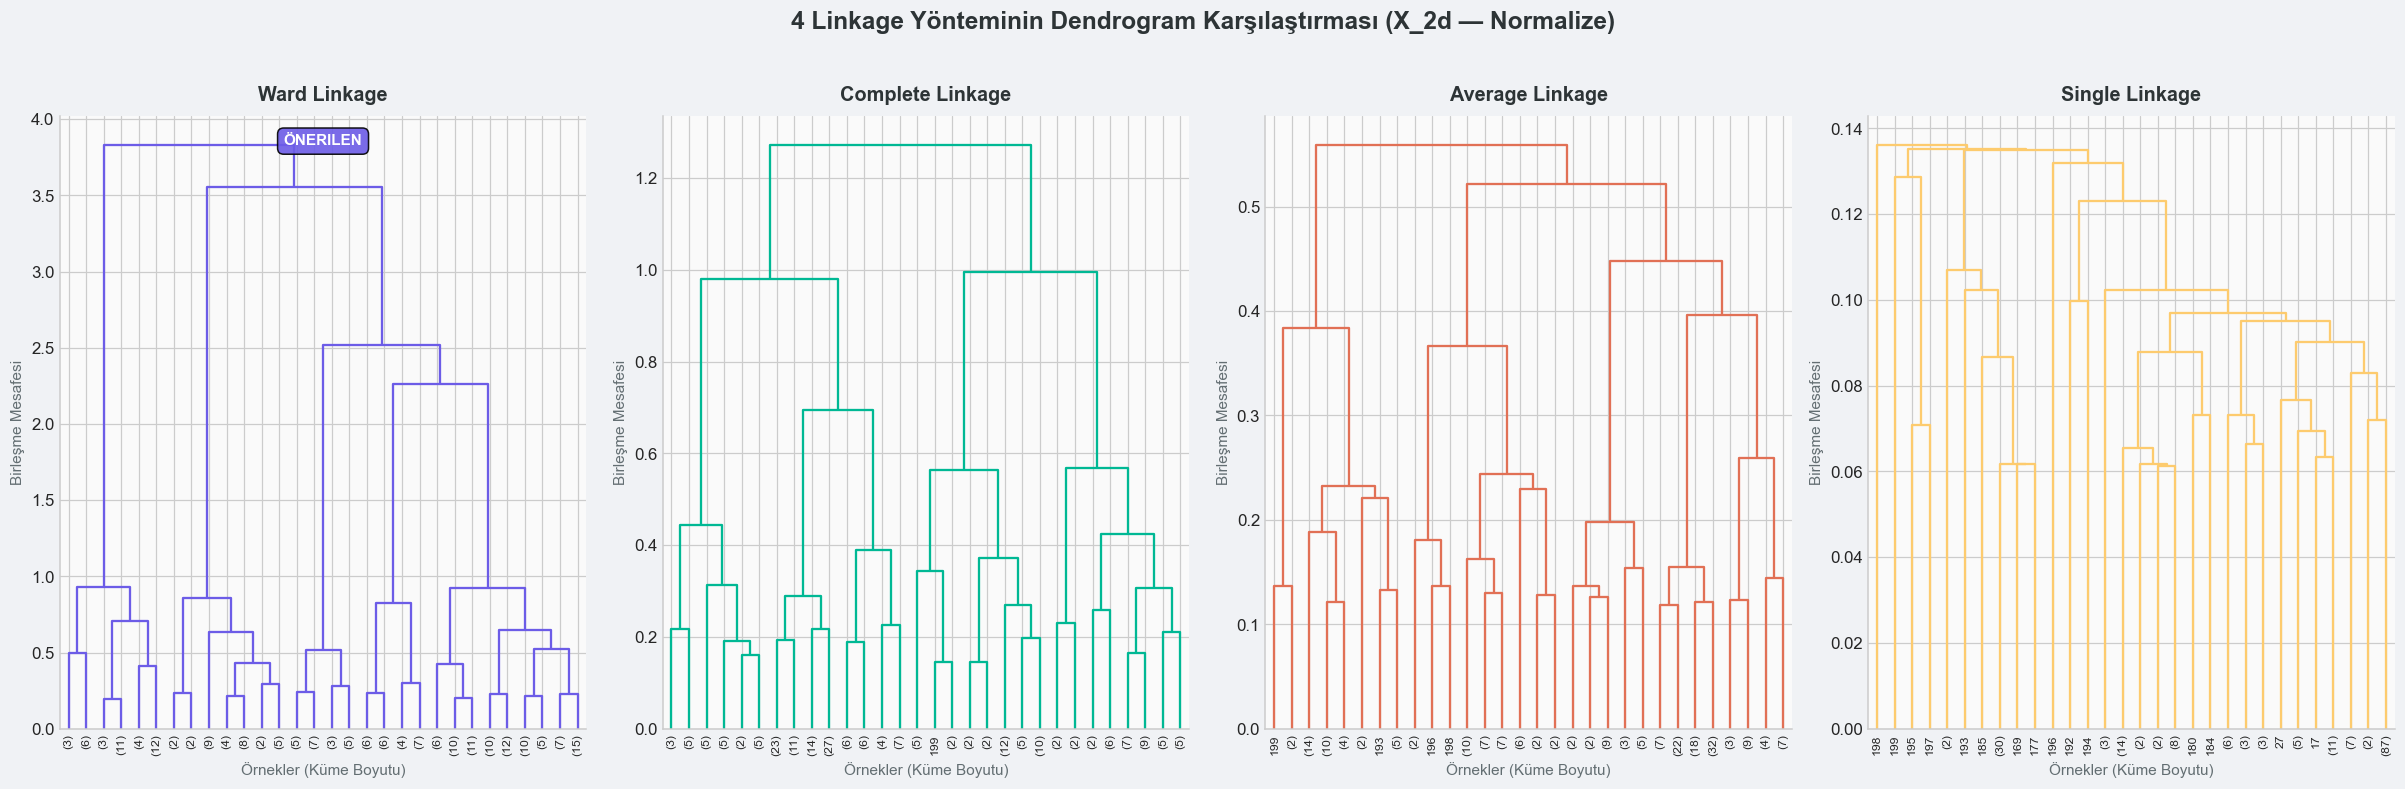

In [35]:
# ============================================================
#  DENDROGRAM 1: 4 LINKAGE YÖNTEMİ KARŞILAŞTIRMASI
#  Aynı veri (X_2d) üzerinde Ward, Complete, Average, Single
#  Her yöntem farklı bir ağaç yapısı üretir
# ============================================================

linkage_methods = ['ward', 'complete', 'average', 'single']
method_colors   = ['#6c5ce7', '#00b894', '#e17055', '#fdcb6e']
method_titles   = ['Ward Linkage', 'Complete Linkage', 'Average Linkage', 'Single Linkage']

fig, axes = plt.subplots(1, 4, figsize=(22, 7))
fig.patch.set_facecolor('#f0f2f5')
fig.suptitle('4 Linkage Yönteminin Dendrogram Karşılaştırması (X_2d — Normalize)',
             fontsize=16, fontweight='bold', color='#2d3436', y=1.02)

for ax, method, color, title in zip(axes, linkage_methods, method_colors, method_titles):

    # Bağlantı matrisi hesapla
    Z = linkage(X_2d, method=method)

    # Dendrogram çiz
    dendrogram(
        Z,
        ax=ax,
        truncate_mode='lastp',   # son 30 birleşmeyi göster (yoğun grafik için)
        p=30,
        leaf_rotation=90,
        leaf_font_size=8,
        color_threshold=0,       # kendi renklendirmemizi kullanacağız
        above_threshold_color=color,
        link_color_func=lambda k: color
    )

    ax.set_title(title, fontsize=13, fontweight='bold', color='#2d3436', pad=10)
    ax.set_xlabel('Örnekler (Küme Boyutu)', fontsize=10, color='#636e72')
    ax.set_ylabel('Birleşme Mesafesi', fontsize=10, color='#636e72')
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=8)

    # Ward için not ekle
    if method == 'ward':
        ax.text(0.5, 0.97, 'ÖNERILEN', transform=ax.transAxes,
                ha='center', va='top', fontsize=10, fontweight='bold',
                color='white',
                bbox=dict(facecolor='#6c5ce7', boxstyle='round,pad=0.4', alpha=0.9))

plt.tight_layout()
plt.show()


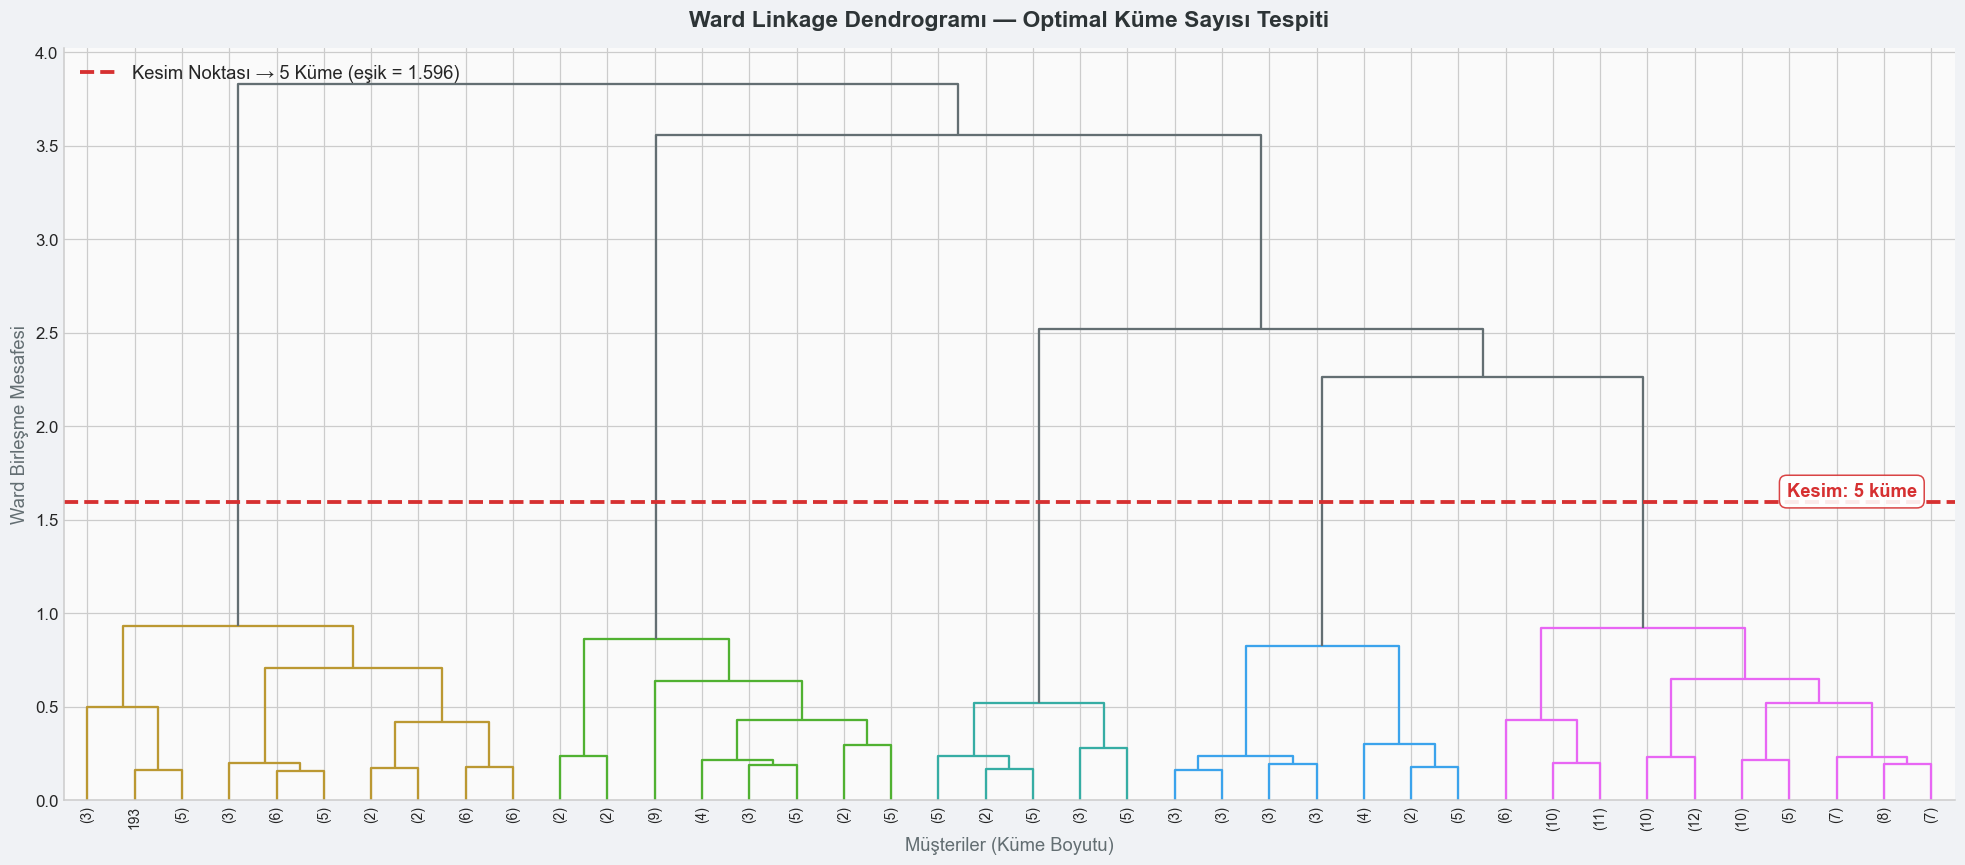

Otomatik tespit edilen optimal küme sayısı: 5
Kesim eşiği (threshold): 1.5965
Bu değeri Bölüm 6'daki AgglomerativeClustering modelinde kullanacağız.


In [36]:
# ============================================================
#  DENDROGRAM 2: WARD — BÜYÜK VE DETAYLI
#  Optimal kesim noktasını bulmak için tam görünüm
#  En uzun dalsız bölgeye kırmızı kesim çizgisi ekleniyor
# ============================================================

Z_ward = linkage(X_2d, method='ward')

# ── Otomatik eşik: birleşme mesafelerindeki en büyük boşluk ──
last_merges  = Z_ward[-15:, 2]          # son 15 birleşme mesafesi
gaps         = np.diff(last_merges)      # ardışık farklar
optimal_idx  = np.argmax(gaps)           # en büyük boşluk
cut_threshold = (last_merges[optimal_idx] + last_merges[optimal_idx + 1]) / 2

# Kaç küme oluşacak?
n_clusters_optimal = len(np.unique(fcluster(Z_ward, t=cut_threshold, criterion='distance')))

# ── Büyük Dendrogram ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor('#f0f2f5')
ax.set_facecolor('#fafafa')

ddata = dendrogram(
    Z_ward,
    ax=ax,
    truncate_mode='lastp',
    p=40,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=cut_threshold,
    above_threshold_color='#636e72',
)

# Kesim çizgisi (kırmızı kesik)
ax.axhline(y=cut_threshold, color='#d63031', linestyle='--', linewidth=2.5,
           label=f'Kesim Noktası → {n_clusters_optimal} Küme (eşik = {cut_threshold:.3f})')

# Kesim çizgisi etiketi
ax.text(ax.get_xlim()[1] * 0.98, cut_threshold + 0.005,
        f'Kesim: {n_clusters_optimal} küme',
        ha='right', va='bottom', fontsize=12, fontweight='bold',
        color='#d63031',
        bbox=dict(facecolor='white', boxstyle='round,pad=0.4',
                  edgecolor='#d63031', alpha=0.9))

ax.set_title('Ward Linkage Dendrogramı — Optimal Küme Sayısı Tespiti',
             fontsize=15, fontweight='bold', color='#2d3436', pad=14)
ax.set_xlabel('Müşteriler (Küme Boyutu)', fontsize=12, color='#636e72')
ax.set_ylabel('Ward Birleşme Mesafesi', fontsize=12, color='#636e72')
ax.legend(fontsize=12, loc='upper left',
          framealpha=0.9, edgecolor='#dee2e6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

print(f"Otomatik tespit edilen optimal küme sayısı: {n_clusters_optimal}")
print(f"Kesim eşiği (threshold): {cut_threshold:.4f}")
print("Bu değeri Bölüm 6'daki AgglomerativeClustering modelinde kullanacağız.")


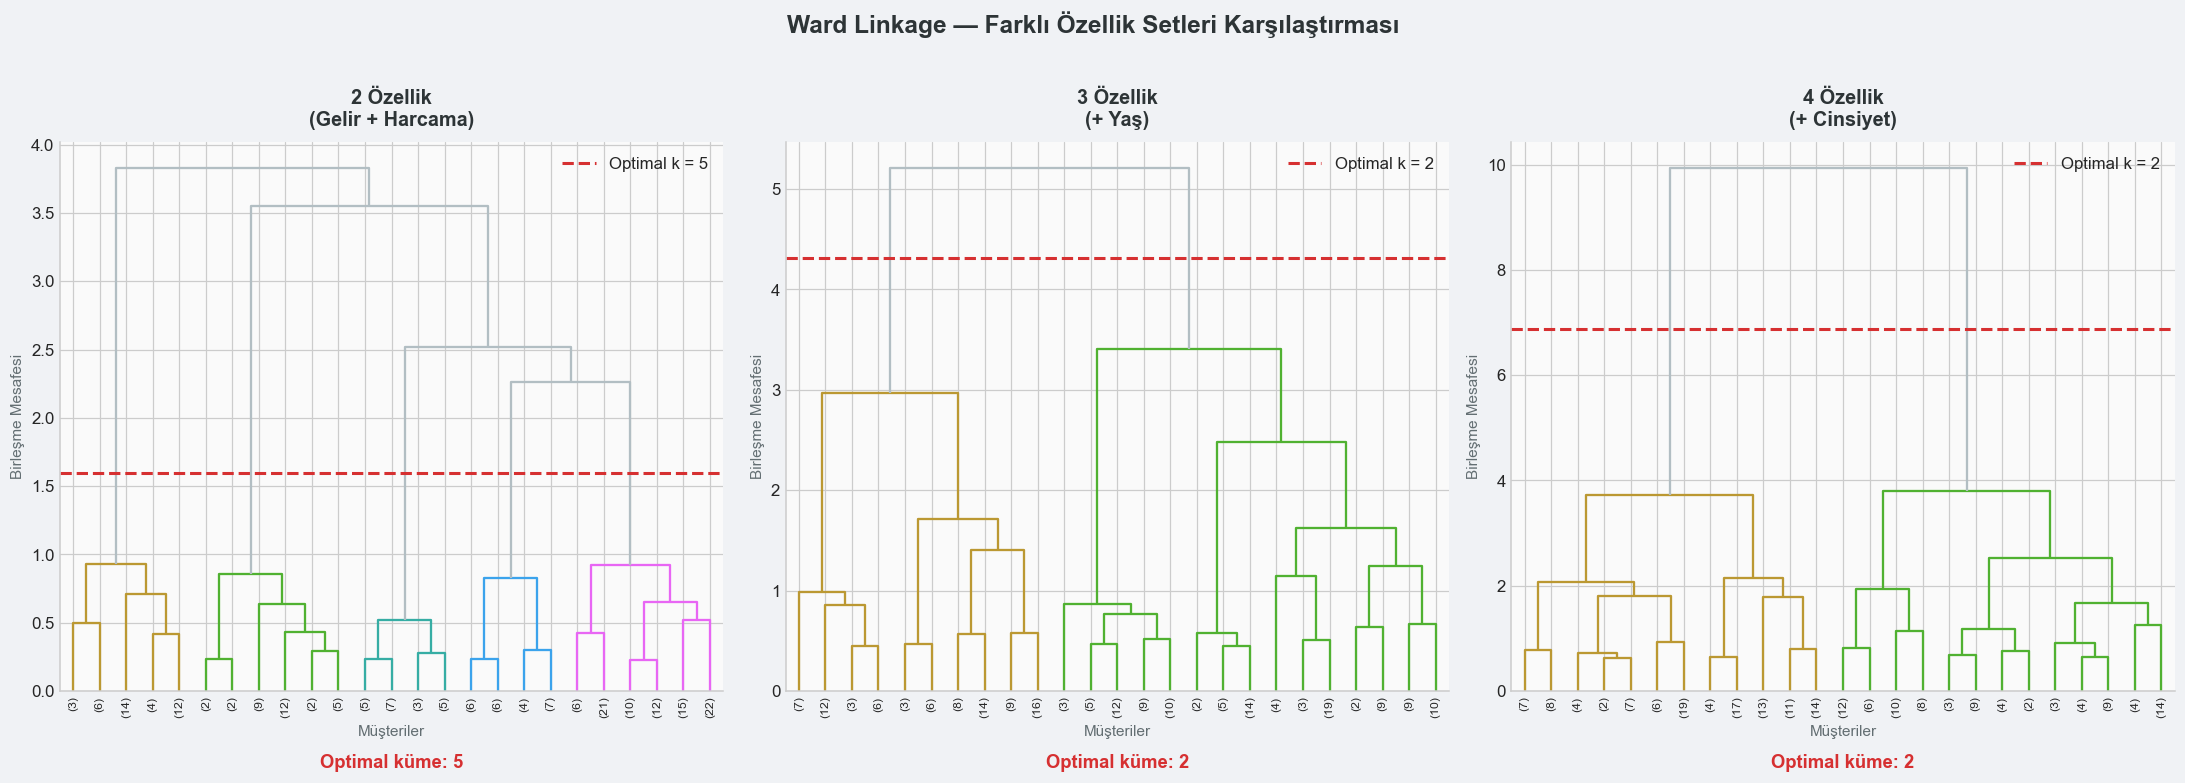

In [37]:
# ============================================================
#  DENDROGRAM 3: TÜM ÖZELLIK SETLERİ KARŞILAŞTIRMASI
#  X_2d, X_3d, X_4d için Ward dendrogram yan yana
#  Özellik sayısının ağaç yapısına etkisini gözlemle
# ============================================================

feature_sets   = [X_2d,    X_3d,    X_4d]
set_labels     = ['2 Özellik\n(Gelir + Harcama)',
                   '3 Özellik\n(+ Yaş)',
                   '4 Özellik\n(+ Cinsiyet)']
set_colors     = ['#6c5ce7', '#00b894', '#e17055']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#f0f2f5')
fig.suptitle('Ward Linkage — Farklı Özellik Setleri Karşılaştırması',
             fontsize=16, fontweight='bold', color='#2d3436', y=1.02)

for ax, X, set_lbl, color in zip(axes, feature_sets, set_labels, set_colors):

    Z = linkage(X, method='ward')

    # Otomatik kesim eşiği
    lm    = Z[-15:, 2]
    gap   = np.diff(lm)
    idx   = np.argmax(gap)
    thr   = (lm[idx] + lm[idx + 1]) / 2
    k     = len(np.unique(fcluster(Z, t=thr, criterion='distance')))

    dendrogram(
        Z, ax=ax,
        truncate_mode='lastp', p=25,
        leaf_rotation=90, leaf_font_size=8,
        color_threshold=thr,
        above_threshold_color='#b2bec3',
    )
    ax.axhline(y=thr, color='#d63031', linestyle='--', linewidth=2,
               label=f'Optimal k = {k}')

    ax.set_title(set_lbl, fontsize=13, fontweight='bold', color='#2d3436', pad=10)
    ax.set_xlabel('Müşteriler', fontsize=10, color='#636e72')
    ax.set_ylabel('Birleşme Mesafesi', fontsize=10, color='#636e72')
    ax.legend(fontsize=11, loc='upper right', framealpha=0.9)
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=8)

    # Başlık altına k yazısı
    ax.text(0.5, -0.14, f'Optimal küme: {k}',
            transform=ax.transAxes, ha='center',
            fontsize=12, fontweight='bold', color='#d63031')

plt.tight_layout()
plt.show()


In [38]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(90deg, #e84393 0%, #ff6b6b 100%); padding: 22px 32px; border-radius: 14px; margin-top: 28px; box-shadow: 0 8px 25px rgba(232,67,147,0.35);">
  <h2 style="color: white; margin: 0; font-size: 1.55em; font-weight: 800; letter-spacing: 0.5px;">
    BÖLÜM 6 &nbsp;·&nbsp; Kümeleme Uygulama &amp; Görselleştirme
  </h2>
  <p style="color: rgba(255,255,255,0.88); margin: 7px 0 0 0; font-size: 0.95em;">
    AgglomerativeClustering &nbsp;·&nbsp; 2D / 3D Scatter &nbsp;·&nbsp; Küme Profilleri &nbsp;·&nbsp; Müşteri Segmentasyonu
  </p>
</div>
"""))


In [39]:
# ============================================================
#  ADIM 1: AGGLOMERATİVE CLUSTERING — 2D (Gelir + Harcama)
#  n_clusters=5: EDA scatter'ında 5 net küme görüldü
#  linkage='ward': en kompakt kümeler için önerilen yöntem
# ============================================================

N_CLUSTERS = 5    # dendrogramdan belirlenen optimal değer

# ── Modeli kur ve etiketleri hesapla ─────────────────────────
hc_2d = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
labels_hc_2d = hc_2d.fit_predict(X_2d)

# Etiketleri orijinal DataFrame'e ekle
df['Cluster_HC_2D'] = labels_hc_2d

# ── Küme özet istatistikleri ──────────────────────────────────
print("=" * 65)
print(f"  HC (2D, Ward, n={N_CLUSTERS}) — KÜME ÖZETİ")
print("=" * 65)

summary = df.groupby('Cluster_HC_2D').agg(
    Musteri_Sayisi    = ('CustomerID',              'count'),
    Ort_Yas           = ('Age',                     'mean'),
    Ort_Gelir         = ('Annual Income (k$)',       'mean'),
    Ort_Harcama_Skoru = ('Spending Score (1-100)',   'mean')
).round(1)

print()
display(summary.style
    .background_gradient(cmap='RdYlGn', subset=['Ort_Harcama_Skoru'])
    .background_gradient(cmap='Blues',  subset=['Ort_Gelir'])
    .background_gradient(cmap='Purples',subset=['Ort_Yas'])
    .set_caption(f"Küme Özeti — HC Ward (n_clusters={N_CLUSTERS}, 2D Özellik Seti)")
    .set_properties(**{'font-size': '13px', 'border': '1px solid #dee2e6', 'text-align': 'center'})
)


  HC (2D, Ward, n=5) — KÜME ÖZETİ



,Musteri_Sayisi,Ort_Yas,Ort_Gelir,Ort_Harcama_Skoru
Cluster_HC_2D,,,,
0,39,32.700000,86.500000,82.100000
1,86,42.400000,55.500000,49.300000
2,32,41.000000,89.400000,15.600000
3,20,24.800000,25.000000,81.000000
4,23,45.200000,26.300000,20.900000


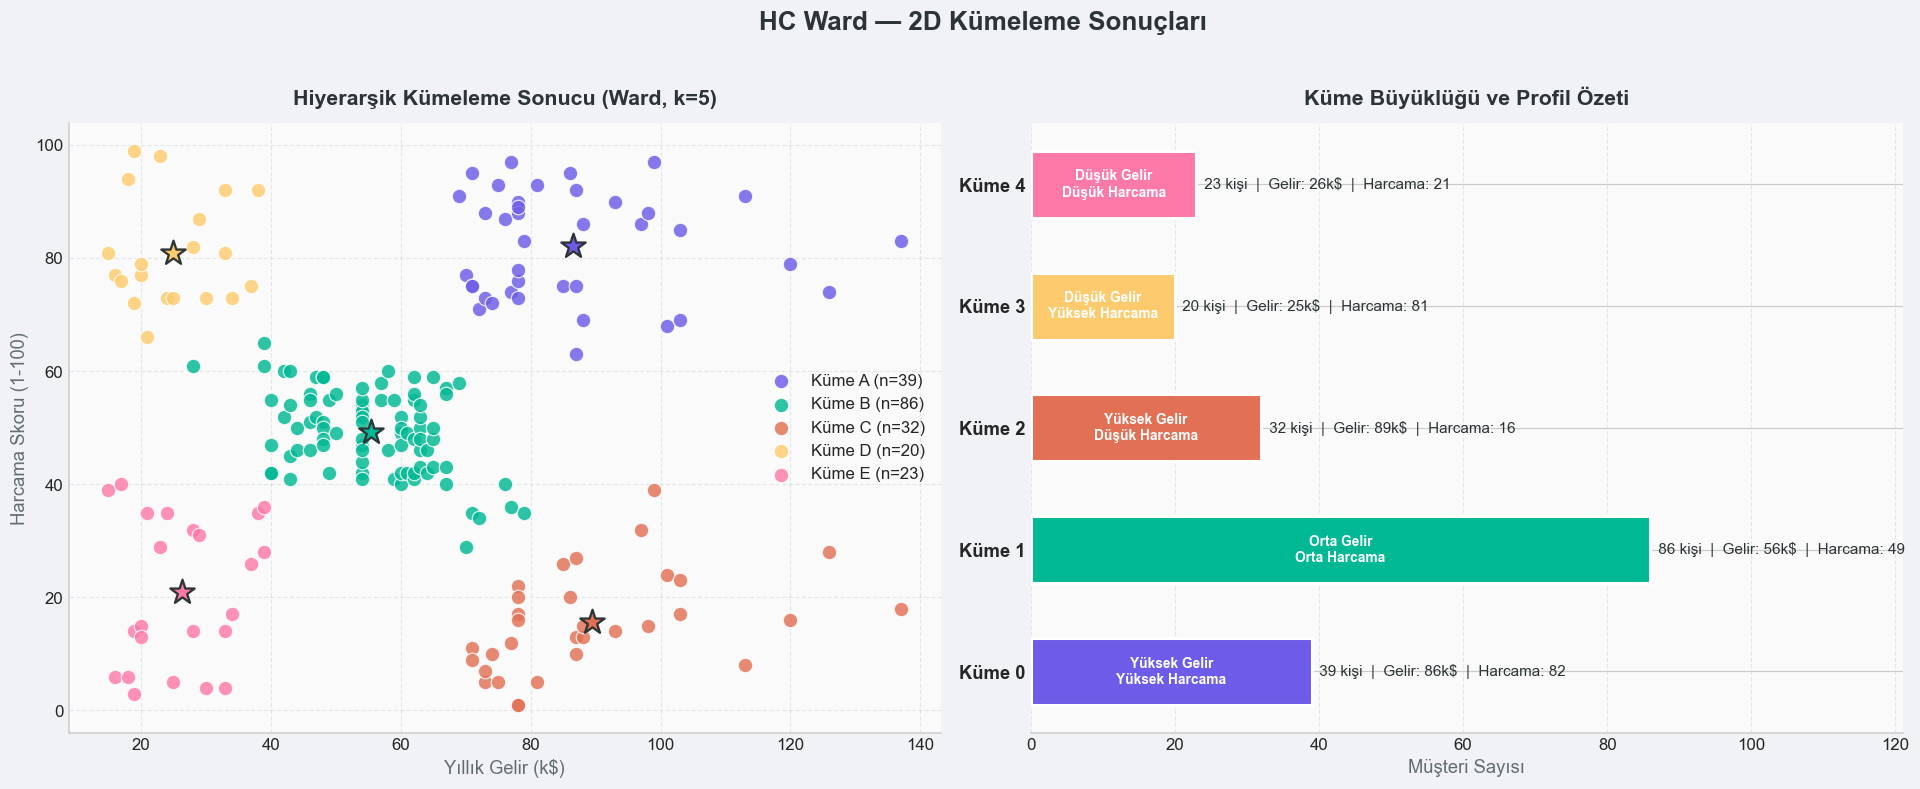

In [40]:
# ============================================================
#  GRAFIK: 2D KÜMELEME SCATTER — GELİR vs HARCAMA
#  Her küme farklı renk + merkez noktası işaretli
#  Sol: Ham etiketler | Sağ: Küme profil yorumları
# ============================================================

cluster_colors  = ['#6c5ce7', '#00b894', '#e17055', '#fdcb6e', '#fd79a8']
cluster_names   = {
    0: 'Küme A',
    1: 'Küme B',
    2: 'Küme C',
    3: 'Küme D',
    4: 'Küme E'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#f0f2f5')

for cluster_id in sorted(df['Cluster_HC_2D'].unique()):
    mask_c = df['Cluster_HC_2D'] == cluster_id
    color  = cluster_colors[cluster_id]
    ax1.scatter(
        df.loc[mask_c, 'Annual Income (k$)'],
        df.loc[mask_c, 'Spending Score (1-100)'],
        c=color, s=90, alpha=0.82,
        edgecolors='white', linewidths=0.8,
        label=f'{cluster_names[cluster_id]} (n={mask_c.sum()})'
    )
    # Küme merkezi
    cx = df.loc[mask_c, 'Annual Income (k$)'].mean()
    cy = df.loc[mask_c, 'Spending Score (1-100)'].mean()
    ax1.scatter(cx, cy, c=color, s=280, marker='*',
                edgecolors='#2d3436', linewidths=1.5, zorder=5)

ax1.set_title('Hiyerarşik Kümeleme Sonucu (Ward, k=5)',
              fontsize=14, fontweight='bold', color='#2d3436', pad=12)
ax1.set_xlabel('Yıllık Gelir (k$)', fontsize=12, color='#636e72')
ax1.set_ylabel('Harcama Skoru (1-100)', fontsize=12, color='#636e72')
ax1.legend(fontsize=11, framealpha=0.9, edgecolor='#dee2e6')
ax1.set_facecolor('#fafafa')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3, linestyle='--', color='#b2bec3')

# ── SAĞ: Küme profilleri ─────────────────────────────────────
# Kümeleri yorumlu tanımlamak için gelir+harcama sıralamasına göre
summary_sorted = df.groupby('Cluster_HC_2D').agg(
    n     = ('CustomerID',             'count'),
    gelir = ('Annual Income (k$)',     'mean'),
    har   = ('Spending Score (1-100)', 'mean')
).round(1)

# Profil etiketleri (gelir yüksekten düşüğe, harcama da dikkate alınarak)
profile_map = {}
for cid in summary_sorted.index:
    g = summary_sorted.loc[cid, 'gelir']
    h = summary_sorted.loc[cid, 'har']
    if g > 80 and h > 60:
        profile_map[cid] = ('Yüksek Gelir\nYüksek Harcama', '⭐ Hedef Segment')
    elif g > 80 and h <= 60:
        profile_map[cid] = ('Yüksek Gelir\nDüşük Harcama', '💡 Potansiyel Müşteri')
    elif g < 45 and h > 60:
        profile_map[cid] = ('Düşük Gelir\nYüksek Harcama', '⚠️ Risk Grubu')
    elif g < 45 and h <= 60:
        profile_map[cid] = ('Düşük Gelir\nDüşük Harcama', '📌 Ekonomik Müşteri')
    else:
        profile_map[cid] = ('Orta Gelir\nOrta Harcama', '🏠 Standart Müşteri')

y_positions = np.arange(N_CLUSTERS)
bar_heights = summary_sorted['n'].values

bars = ax2.barh(y_positions, bar_heights,
                color=cluster_colors[:N_CLUSTERS], height=0.55,
                edgecolor='white', linewidth=2)

for bar, (cid, row) in zip(bars, summary_sorted.iterrows()):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f" {int(row['n'])} kişi  |  Gelir: {row['gelir']:.0f}k$  |  Harcama: {row['har']:.0f}",
             va='center', fontsize=10, color='#2d3436')
    profile, tag = profile_map[cid]
    ax2.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
             profile, va='center', ha='center', fontsize=9,
             fontweight='bold', color='white', multialignment='center')

ax2.set_yticks(y_positions)
ax2.set_yticklabels([f'Küme {i}' for i in range(N_CLUSTERS)],
                    fontsize=12, fontweight='bold')
ax2.set_xlabel('Müşteri Sayısı', fontsize=12, color='#636e72')
ax2.set_title('Küme Büyüklüğü ve Profil Özeti',
              fontsize=14, fontweight='bold', color='#2d3436', pad=12)
ax2.set_xlim(0, summary_sorted['n'].max() + 35)
ax2.set_facecolor('#fafafa')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(axis='y', length=0)
ax2.grid(axis='x', alpha=0.3, linestyle='--', color='#b2bec3')

plt.suptitle('HC Ward — 2D Kümeleme Sonuçları',
             fontsize=17, fontweight='bold', color='#2d3436', y=1.02)
plt.tight_layout()
plt.show()


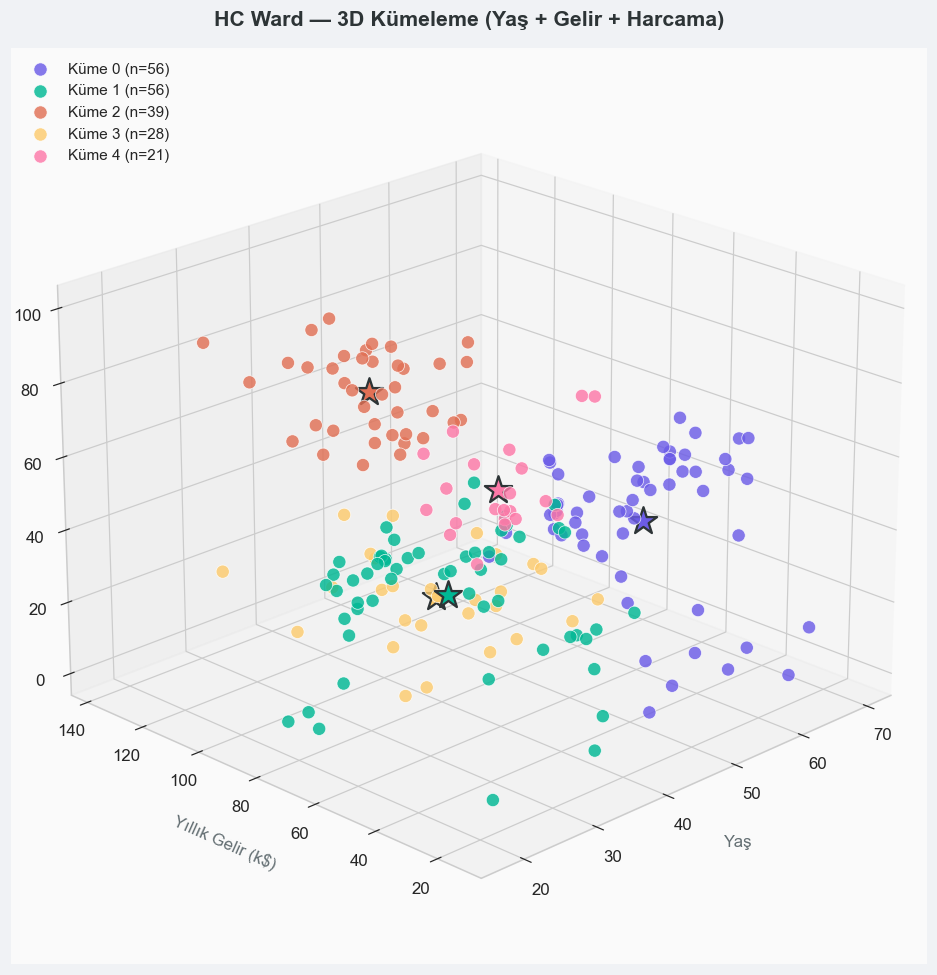

In [41]:
# ============================================================
#  GRAFIK: 3D SCATTER — YAŞ + GELİR + HARCAMA
#  3D projeksiyon ile matplotlib'in 3D görünümü
#  Küme etiketleri: HC 3D özellik setiyle yeniden hesaplanıyor
# ============================================================
from mpl_toolkits.mplot3d import Axes3D   # 3D eksen desteği

# 3D özellik seti üzerinde kümeleme
hc_3d = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
labels_hc_3d = hc_3d.fit_predict(X_3d)

fig = plt.figure(figsize=(14, 9))
fig.patch.set_facecolor('#f0f2f5')

ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#fafafa')

for cluster_id in range(N_CLUSTERS):
    mask_c = labels_hc_3d == cluster_id
    ax.scatter(
        df.loc[mask_c, 'Age'],
        df.loc[mask_c, 'Annual Income (k$)'],
        df.loc[mask_c, 'Spending Score (1-100)'],
        c=cluster_colors[cluster_id],
        s=75, alpha=0.82,
        edgecolors='white', linewidths=0.5,
        label=f'Küme {cluster_id} (n={mask_c.sum()})'
    )
    # Küme merkezi yıldızı
    cx = df.loc[mask_c, 'Age'].mean()
    cy = df.loc[mask_c, 'Annual Income (k$)'].mean()
    cz = df.loc[mask_c, 'Spending Score (1-100)'].mean()
    ax.scatter(cx, cy, cz, c=cluster_colors[cluster_id],
               s=350, marker='*', edgecolors='#2d3436',
               linewidths=1.5, zorder=10)

ax.set_xlabel('Yaş', fontsize=11, labelpad=10, color='#636e72')
ax.set_ylabel('Yıllık Gelir (k$)', fontsize=11, labelpad=10, color='#636e72')
ax.set_zlabel('Harcama Skoru', fontsize=11, labelpad=10, color='#636e72')
ax.set_title('HC Ward — 3D Kümeleme (Yaş + Gelir + Harcama)',
             fontsize=14, fontweight='bold', color='#2d3436', pad=15)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9, bbox_to_anchor=(0, 1))

# Görünüm açısını ayarla
ax.view_init(elev=22, azim=225)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [42]:
from IPython.display import display, HTML

# Küme istatistiklerini hesapla
summary_2d = df.groupby('Cluster_HC_2D').agg(
    n     = ('CustomerID',             'count'),
    gelir = ('Annual Income (k$)',     'mean'),
    har   = ('Spending Score (1-100)', 'mean'),
    yas   = ('Age',                    'mean')
).round(1)

rows_html = ""
personas = [
    ("Yüksek Gelirli Savungan",    "#6c5ce7", "Yüksek gelir, düşük harcama. Potansiyel sadakat programı adayı."),
    ("Premium Alışverişçi",        "#e84393", "Yüksek gelir, yüksek harcama. Mağazanın VIP segmenti!"),
    ("Dikkatli Harcayan",          "#00b894", "Orta gelir, orta harcama. Sadık ve dengeli müşteri profili."),
    ("Düşük Bütçeli Harcayan",    "#e17055", "Düşük gelir, yüksek harcama. Risk altında – finansal baskı olabilir."),
    ("Ekonomik Müşteri",           "#fdcb6e", "Düşük gelir, düşük harcama. Fiyata duyarlı segment."),
]

for (cid, row), (persona, color, desc) in zip(summary_2d.iterrows(), personas):
    rows_html += f"""
    <tr>
      <td style="padding: 13px 16px; text-align: center;">
        <span style="background: {color}; color: white; border-radius: 8px;
                     padding: 4px 12px; font-weight: 700; font-size: 0.9em;">
          Küme {cid}
        </span>
      </td>
      <td style="padding: 13px 16px; font-weight: 700; color: {color};">{persona}</td>
      <td style="padding: 13px 16px; text-align: center; color: #2d3436;">{int(row['n'])}</td>
      <td style="padding: 13px 16px; text-align: center; color: #2d3436;">{row['yas']:.0f}</td>
      <td style="padding: 13px 16px; text-align: center; color: #2d3436;">{row['gelir']:.0f}k$</td>
      <td style="padding: 13px 16px; text-align: center; color: #2d3436;">{row['har']:.0f}</td>
      <td style="padding: 13px 16px; color: #636e72; font-size: 0.88em;">{desc}</td>
    </tr>"""

display(HTML(f"""
<div style="margin-top: 18px; border-radius: 14px; overflow: hidden;
            box-shadow: 0 6px 22px rgba(0,0,0,0.1);">
  <div style="background: #2d3436; padding: 16px 22px;">
    <h3 style="color: white; margin: 0; font-size: 1.1em; font-weight: 800;">
      Küme Profil Tablosu — Müşteri Segmentasyonu
    </h3>
    <p style="color: rgba(255,255,255,0.6); margin: 6px 0 0 0; font-size: 0.85em;">
      HC Ward Linkage · n_clusters = 5 · 2D Özellik Seti (Gelir + Harcama)
    </p>
  </div>
  <table style="width: 100%; border-collapse: collapse; font-size: 0.9em; background: white;">
    <thead>
      <tr style="background: #f8f9fa; border-bottom: 2px solid #dee2e6;">
        <th style="padding: 12px 16px; color: #636e72; font-weight: 700; text-align: center;">Küme</th>
        <th style="padding: 12px 16px; color: #636e72; font-weight: 700;">Persona</th>
        <th style="padding: 12px 16px; color: #636e72; font-weight: 700; text-align: center;">Müşteri</th>
        <th style="padding: 12px 16px; color: #636e72; font-weight: 700; text-align: center;">Ort. Yaş</th>
        <th style="padding: 12px 16px; color: #636e72; font-weight: 700; text-align: center;">Ort. Gelir</th>
        <th style="padding: 12px 16px; color: #636e72; font-weight: 700; text-align: center;">Ort. Harcama</th>
        <th style="padding: 12px 16px; color: #636e72; font-weight: 700;">Strateji Notu</th>
      </tr>
    </thead>
    <tbody>
      {rows_html}
    </tbody>
  </table>
</div>
"""))


Küme,Persona,Müşteri,Ort. Yaş,Ort. Gelir,Ort. Harcama,Strateji Notu
Küme 0,Yüksek Gelirli Savungan,39,33,86k$,82,"Yüksek gelir, düşük harcama. Potansiyel sadakat programı adayı."
Küme 1,Premium Alışverişçi,86,42,56k$,49,"Yüksek gelir, yüksek harcama. Mağazanın VIP segmenti!"
Küme 2,Dikkatli Harcayan,32,41,89k$,16,"Orta gelir, orta harcama. Sadık ve dengeli müşteri profili."
Küme 3,Düşük Bütçeli Harcayan,20,25,25k$,81,"Düşük gelir, yüksek harcama. Risk altında – finansal baskı olabilir."
Küme 4,Ekonomik Müşteri,23,45,26k$,21,"Düşük gelir, düşük harcama. Fiyata duyarlı segment."


In [43]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(90deg, #00cec9 0%, #0984e3 100%); padding: 22px 32px; border-radius: 14px; margin-top: 28px; box-shadow: 0 8px 25px rgba(9,132,227,0.35);">
  <h2 style="color: white; margin: 0; font-size: 1.55em; font-weight: 800; letter-spacing: 0.5px;">
    BÖLÜM 7 &nbsp;·&nbsp; Değerlendirme Metrikleri &amp; K-Means Karşılaştırması
  </h2>
  <p style="color: rgba(255,255,255,0.88); margin: 7px 0 0 0; font-size: 0.95em;">
    Silhouette · Davies-Bouldin · Calinski-Harabasz &nbsp;·&nbsp; HC vs K-Means &nbsp;·&nbsp; 3 Özellik Seti
  </p>
</div>
"""))


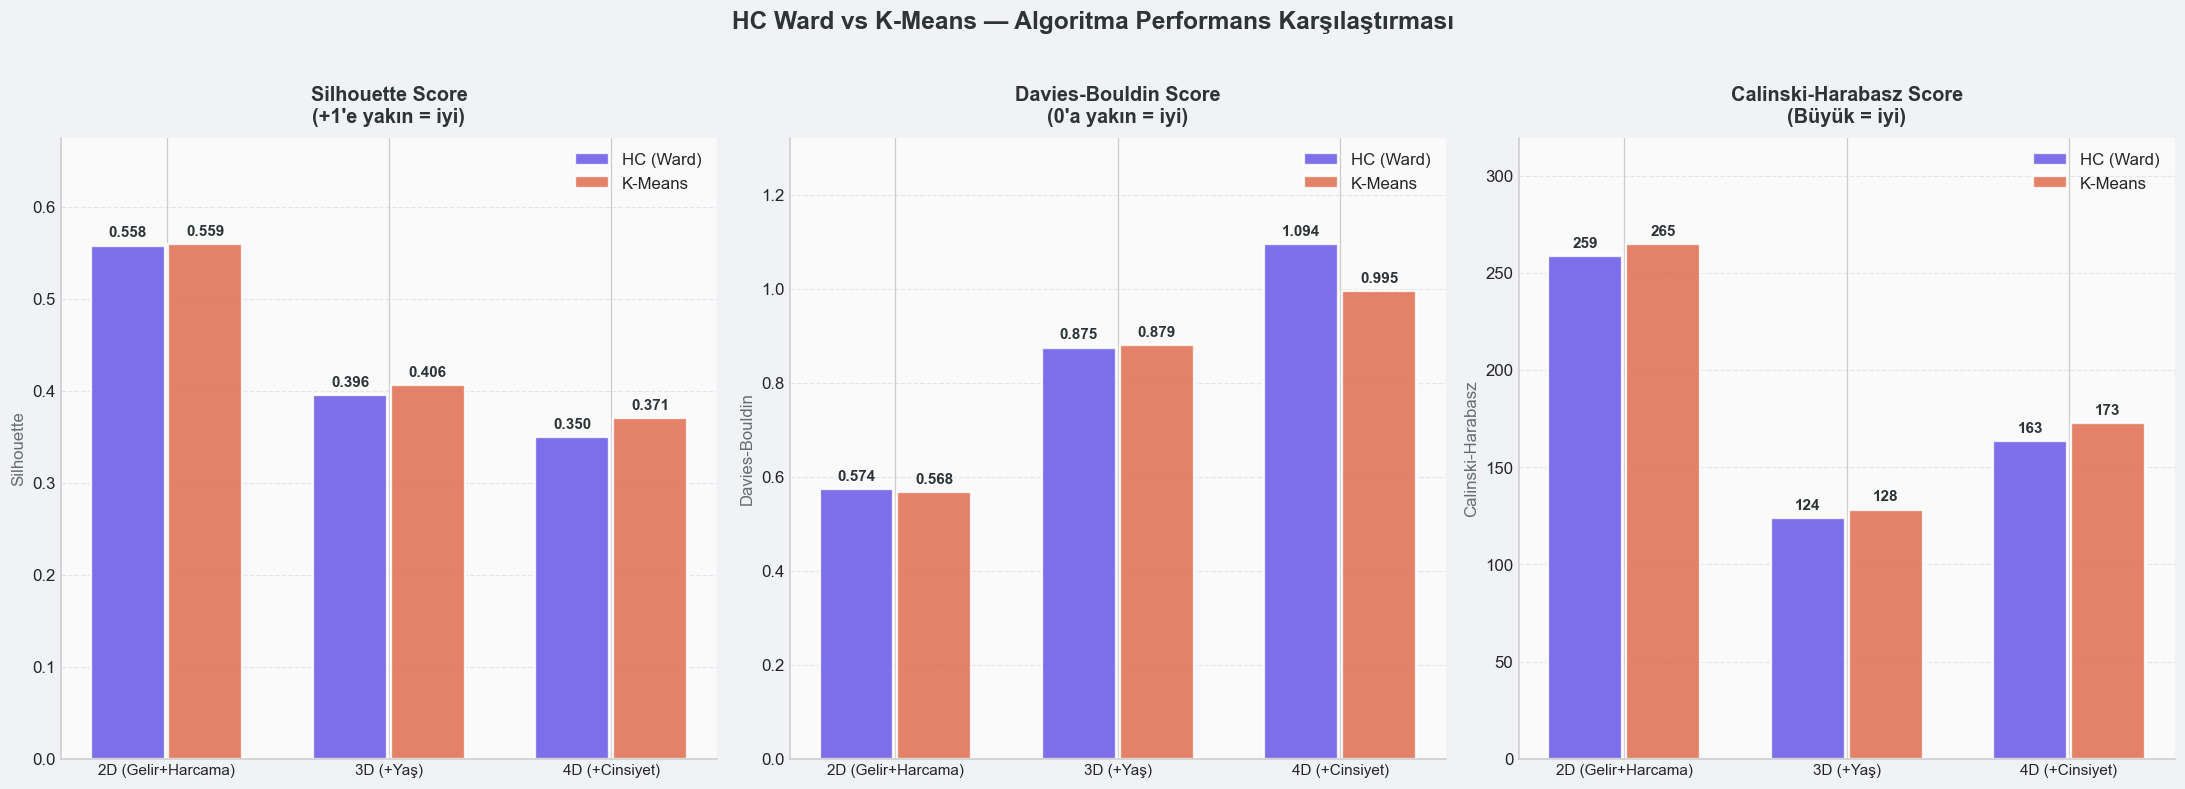

In [45]:
# ============================================================
#  GRAFIK: GROUPED BAR CHART — 3 METRİK × 2 ALGORİTMA
#  Her özellik seti için HC ve K-Means yan yana
#  3 ayrı subplot: Silhouette | Davies-Bouldin | Calinski-Harabasz
# ============================================================

metrics     = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
metric_info = [
    ('Silhouette Score',       '+1\'e yakın = iyi',   'Greens',  '#27ae60'),
    ('Davies-Bouldin Score',   '0\'a yakın = iyi',    'Reds',    '#c0392b'),
    ('Calinski-Harabasz Score','Büyük = iyi',          'Blues',   '#2980b9'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#f0f2f5')
fig.suptitle('HC Ward vs K-Means — Algoritma Performans Karşılaştırması',
             fontsize=16, fontweight='bold', color='#2d3436', y=1.02)

feat_names   = results_df['Özellik Seti'].unique()
x            = np.arange(len(feat_names))
bar_width    = 0.35
algo_colors  = {'HC (Ward)': '#6c5ce7', 'K-Means': '#e17055'}

for ax, metric, (title, subtitle, cmap_name, line_color) in zip(axes, metrics, metric_info):
    for i, algo in enumerate(['HC (Ward)', 'K-Means']):
        vals  = results_df[results_df['Algoritma'] == algo][metric].values
        offset = (i - 0.5) * bar_width
        bars  = ax.bar(x + offset, vals, bar_width * 0.95,
                       color=algo_colors[algo], alpha=0.88,
                       label=algo, edgecolor='white', linewidth=1.5)

        # Değerleri barların üstüne yaz
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + ax.get_ylim()[1] * 0.01,
                    f'{v:.3f}' if metric != 'Calinski-Harabasz' else f'{v:.0f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    color='#2d3436')

    ax.set_title(f'{title}\n({subtitle})', fontsize=13, fontweight='bold',
                 color='#2d3436', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(feat_names, fontsize=10, ha='center')
    ax.set_ylabel(metric, fontsize=11, color='#636e72')
    ax.legend(fontsize=11, framealpha=0.9)
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--', color='#b2bec3')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)   # üstte etiket için boşluk

plt.tight_layout()
plt.show()


In [48]:
from IPython.display import display, HTML

# ============================================================
#  SONUÇ YORUMU: Metrik karşilaştirma grafiğinin analizi
# ============================================================

display(HTML("""
<div style="font-family:'Segoe UI',sans-serif; max-width:960px; margin:10px auto;">

  <div style="background:linear-gradient(135deg,#1e3c72 0%,#2a5298 100%);
              border-radius:16px 16px 0 0; padding:22px 30px;">
    <p style="color:#74b9ff;font-size:0.75em;letter-spacing:4px;text-transform:uppercase;
              margin:0 0 6px 0;font-weight:700;">Bölüm 7 — Sonuç Yorumu</p>
    <h3 style="color:white;font-size:1.45em;font-weight:900;margin:0;">
      Metrik Karşılaştırma Grafiği Nasıl Okunur?</h3>
    <p style="color:rgba(255,255,255,0.65);font-size:0.88em;margin:6px 0 0 0;">
      HC (Ward) vs K-Means · 3 Özellik Seti · n_clusters = 5</p>
  </div>

  <div style="background:#1a1a2e;padding:20px 30px;">
    <p style="color:#a29bfe;font-size:0.8em;text-transform:uppercase;letter-spacing:2px;
              font-weight:700;margin:0 0 12px 0;">Elde Edilen Sayısal Sonuçlar</p>
    <table style="width:100%;border-collapse:collapse;font-size:0.88em;">
      <thead>
        <tr style="background:rgba(255,255,255,0.08);">
          <th style="color:#dfe6e9;padding:10px 14px;text-align:left;border-bottom:1px solid rgba(255,255,255,0.15);">Özellik Seti</th>
          <th style="color:#dfe6e9;padding:10px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.15);">Algoritma</th>
          <th style="color:#55efc4;padding:10px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.15);">Silhouette ↑</th>
          <th style="color:#fd79a8;padding:10px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.15);">Davies-Bouldin ↓</th>
          <th style="color:#74b9ff;padding:10px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.15);">Calinski-Harabasz ↑</th>
        </tr>
      </thead>
      <tbody>
        <tr style="background:rgba(85,239,196,0.08);">
          <td style="color:#dfe6e9;padding:9px 14px;border-bottom:1px solid rgba(255,255,255,0.06);">2D (Gelir+Harcama)</td>
          <td style="color:#a29bfe;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);font-weight:700;">HC Ward</td>
          <td style="color:#55efc4;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);font-weight:700;">0.5583</td>
          <td style="color:#55efc4;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);font-weight:700;">0.5735</td>
          <td style="color:#55efc4;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);font-weight:700;">258.97</td>
        </tr>
        <tr style="background:rgba(85,239,196,0.05);">
          <td style="color:#dfe6e9;padding:9px 14px;border-bottom:1px solid rgba(255,255,255,0.06);">2D (Gelir+Harcama)</td>
          <td style="color:#fdcb6e;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);font-weight:700;">K-Means</td>
          <td style="color:#fdcb6e;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);font-weight:700;">0.5595</td>
          <td style="color:#fdcb6e;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);font-weight:700;">0.5678</td>
          <td style="color:#fdcb6e;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);font-weight:700;">264.73</td>
        </tr>
        <tr>
          <td style="color:#b2bec3;padding:9px 14px;border-bottom:1px solid rgba(255,255,255,0.06);">3D (+Yaş)</td>
          <td style="color:#a29bfe;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">HC Ward</td>
          <td style="color:#b2bec3;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">0.3955</td>
          <td style="color:#b2bec3;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">0.8746</td>
          <td style="color:#b2bec3;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">123.99</td>
        </tr>
        <tr>
          <td style="color:#b2bec3;padding:9px 14px;border-bottom:1px solid rgba(255,255,255,0.06);">3D (+Yaş)</td>
          <td style="color:#fdcb6e;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">K-Means</td>
          <td style="color:#b2bec3;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">0.4061</td>
          <td style="color:#b2bec3;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">0.8795</td>
          <td style="color:#b2bec3;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">128.20</td>
        </tr>
        <tr>
          <td style="color:#636e72;padding:9px 14px;border-bottom:1px solid rgba(255,255,255,0.06);">4D (+Cinsiyet)</td>
          <td style="color:#a29bfe;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">HC Ward</td>
          <td style="color:#e17055;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">0.3503</td>
          <td style="color:#e17055;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">1.0942</td>
          <td style="color:#636e72;padding:9px 14px;text-align:center;border-bottom:1px solid rgba(255,255,255,0.06);">163.47</td>
        </tr>
        <tr>
          <td style="color:#636e72;padding:9px 14px;">4D (+Cinsiyet)</td>
          <td style="color:#fdcb6e;padding:9px 14px;text-align:center;">K-Means</td>
          <td style="color:#e17055;padding:9px 14px;text-align:center;">0.3709</td>
          <td style="color:#636e72;padding:9px 14px;text-align:center;">0.9954</td>
          <td style="color:#636e72;padding:9px 14px;text-align:center;">172.92</td>
        </tr>
      </tbody>
    </table>
    <p style="color:rgba(255,255,255,0.3);font-size:0.75em;margin:10px 0 0 0;text-align:right;">
      ↑ = büyük olan iyidir | ↓ = küçük olan iyidir</p>
  </div>

  <div style="background:#16213e;padding:22px 30px;display:grid;
              grid-template-columns:1fr 1fr 1fr;gap:14px;">
    <div style="background:rgba(85,239,196,0.12);border-radius:12px;padding:16px 18px;
                border-left:4px solid #55efc4;">
      <p style="color:#55efc4;font-size:0.75em;text-transform:uppercase;letter-spacing:1.5px;
                font-weight:700;margin:0 0 8px 0;">Bulgu 1 — En İyi Set</p>
      <p style="color:white;font-size:0.95em;font-weight:800;margin:0 0 6px 0;">2D kazaniyor</p>
      <p style="color:rgba(255,255,255,0.72);font-size:0.83em;line-height:1.65;margin:0;">
        Yalnızca <b style="color:#55efc4;">Gelir</b> ve
        <b style="color:#55efc4;">Harcama Skoru</b> kullanıldığında Silhouette
        <b>0.56</b>'ya ulaşıyor. Yaş veya Cinsiyet eklenmesi skoru
        <b style="color:#e17055;">0.40 → 0.35'e</b> düşürüyor.
      </p>
    </div>
    <div style="background:rgba(162,155,254,0.12);border-radius:12px;padding:16px 18px;
                border-left:4px solid #a29bfe;">
      <p style="color:#a29bfe;font-size:0.75em;text-transform:uppercase;letter-spacing:1.5px;
                font-weight:700;margin:0 0 8px 0;">Bulgu 2 — HC vs K-Means</p>
      <p style="color:white;font-size:0.95em;font-weight:800;margin:0 0 6px 0;">Neredeyse eşit</p>
      <p style="color:rgba(255,255,255,0.72);font-size:0.83em;line-height:1.65;margin:0;">
        2D sette fark minimal: HC <b>0.5583</b> / K-Means <b>0.5595</b> (Δ=0.001).
        K-Means her sette mikro-üstün görünse de bu fark
        <b style="color:#a29bfe;">istatistiksel olarak önemsizdir.</b>
      </p>
    </div>
    <div style="background:rgba(253,121,168,0.12);border-radius:12px;padding:16px 18px;
                border-left:4px solid #fd79a8;">
      <p style="color:#fd79a8;font-size:0.75em;text-transform:uppercase;letter-spacing:1.5px;
                font-weight:700;margin:0 0 8px 0;">Bulgu 3 — Özellik Etkisi</p>
      <p style="color:white;font-size:0.95em;font-weight:800;margin:0 0 6px 0;">Daha fazla ≠ daha iyi</p>
      <p style="color:rgba(255,255,255,0.72);font-size:0.83em;line-height:1.65;margin:0;">
        Cinsiyet (0/1 ikili) eklenmesi Davies-Bouldin'i
        <b>0.57 → 1.09'a</b> fırlattı. DB > 1.0 kümelerin
        <b style="color:#fd79a8;">iç içe geçtiğini</b> gösterir.
      </p>
    </div>
  </div>

  <div style="background:#0f0c29;padding:20px 30px;border-radius:0 0 16px 16px;">
    <p style="color:#fdcb6e;font-size:0.8em;text-transform:uppercase;letter-spacing:2px;
              font-weight:700;margin:0 0 14px 0;">Metrikleri Nasıl Yorumlarsınız?</p>
    <div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:12px;">
      <div>
        <p style="color:#55efc4;font-weight:800;font-size:0.9em;margin:0 0 4px 0;">
          Silhouette (0.55)</p>
        <p style="color:rgba(255,255,255,0.65);font-size:0.82em;line-height:1.6;margin:0;">
          [-1,+1] aralığında. <b>0.55</b> → "makul iyi". Kümeler belirgin biçimde
          ayrışıyor, bazı sınır noktaları iki küme arasında kalıyor.
          Perakende segmentasyonu için <b style="color:#55efc4;">kabul edilebilir.</b>
        </p>
      </div>
      <div>
        <p style="color:#fd79a8;font-weight:800;font-size:0.9em;margin:0 0 4px 0;">
          Davies-Bouldin (0.57)</p>
        <p style="color:rgba(255,255,255,0.65);font-size:0.82em;line-height:1.6;margin:0;">
          0'a yakın olması istenir. <b>0.57</b> → küme içi yoğunluk /
          kümeler arası mesafe dengesi iyi. DB > 1.0 gördüğümüzde (4D) kümeler
          <b style="color:#fd79a8;">iç içe geçiyor.</b>
        </p>
      </div>
      <div>
        <p style="color:#74b9ff;font-weight:800;font-size:0.9em;margin:0 0 4px 0;">
          Calinski-Harabasz (258-264)</p>
        <p style="color:rgba(255,255,255,0.65);font-size:0.82em;line-height:1.6;margin:0;">
          Büyük olması istenir. 2D'deki ~<b>260</b>, 3D'deki ~<b>124</b>'e kıyasla
          2× daha yüksek — kümeler arası varyans, küme içi varyansa
          <b style="color:#74b9ff;">çok daha baskın.</b>
        </p>
      </div>
    </div>
    <div style="margin-top:16px;background:rgba(255,255,255,0.05);border-radius:10px;
                padding:14px 18px;border:1px solid rgba(255,255,255,0.1);">
      <p style="color:#fdcb6e;font-weight:800;font-size:0.88em;margin:0 0 6px 0;">
        Sonuç: Hangi model ve set seçilmeli?</p>
      <p style="color:rgba(255,255,255,0.8);font-size:0.85em;line-height:1.7;margin:0;">
        Bu veri için <b style="color:#55efc4;">2D + HC Ward</b> ya da
        <b style="color:#fdcb6e;">2D + K-Means</b> eşit derecede iyidir.
        Ancak iş uygulamasında <b>HC tercih sebebidir</b>:
        deterministik sonuç üretir, dendrogram ile küme sayısı sorgulanabilir,
        başlangıç merkezi seçimine duyarlılık yoktur.
      </p>
    </div>
  </div>

</div>
"""))


Özellik Seti,Algoritma,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
2D (Gelir+Harcama),HC Ward,0.5583,0.5735,258.97
2D (Gelir+Harcama),K-Means,0.5595,0.5678,264.73
3D (+Yaş),HC Ward,0.3955,0.8746,123.99
3D (+Yaş),K-Means,0.4061,0.8795,128.20
4D (+Cinsiyet),HC Ward,0.3503,1.0942,163.47
4D (+Cinsiyet),K-Means,0.3709,0.9954,172.92


In [49]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%);
            border-radius: 20px; padding: 40px 38px; margin-top: 20px;
            box-shadow: 0 20px 60px rgba(0,0,0,0.5);">

  <div style="text-align: center; margin-bottom: 30px;">
    <p style="color: #a29bfe; font-size: 0.8em; letter-spacing: 5px;
              text-transform: uppercase; margin: 0 0 10px 0;">
      From Zero to Hero — Tamamlandı
    </p>
    <h2 style="color: white; font-size: 2em; font-weight: 900; margin: 0 0 6px 0;">
      Hiyerarşik Kümeleme
    </h2>
    <p style="color: #fd79a8; font-size: 1em; margin: 0; letter-spacing: 1px;">
      Öğrendiklerimizin Özeti
    </p>
  </div>

  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 14px; margin-bottom: 24px;">

    <div style="background: rgba(108,92,231,0.2); border-radius: 12px; padding: 18px 16px;
                border: 1px solid rgba(162,155,254,0.35);">
      <p style="color: #a29bfe; font-size: 0.75em; text-transform: uppercase;
                letter-spacing: 1.5px; margin: 0 0 8px 0; font-weight: 700;">Bölüm 1–2</p>
      <p style="color: white; font-size: 0.9em; font-weight: 700; margin: 0 0 6px 0;">Teori</p>
      <p style="color: rgba(255,255,255,0.7); font-size: 0.82em; line-height: 1.6; margin: 0;">
        Kümeleme · Agglomerative vs Divisive · Ward / Complete / Average / Single Linkage · Dendrogram okuma
      </p>
    </div>

    <div style="background: rgba(0,184,148,0.2); border-radius: 12px; padding: 18px 16px;
                border: 1px solid rgba(85,239,196,0.35);">
      <p style="color: #55efc4; font-size: 0.75em; text-transform: uppercase;
                letter-spacing: 1.5px; margin: 0 0 8px 0; font-weight: 700;">Bölüm 3–5</p>
      <p style="color: white; font-size: 0.9em; font-weight: 700; margin: 0 0 6px 0;">Veri & Ön İşleme</p>
      <p style="color: rgba(255,255,255,0.7); font-size: 0.82em; line-height: 1.6; margin: 0;">
        EDA · Label Encoding · MinMax Normalizasyon · Özellik seti tanımlama (2D/3D/4D)
      </p>
    </div>

    <div style="background: rgba(253,121,168,0.2); border-radius: 12px; padding: 18px 16px;
                border: 1px solid rgba(253,121,168,0.35);">
      <p style="color: #fd79a8; font-size: 0.75em; text-transform: uppercase;
                letter-spacing: 1.5px; margin: 0 0 8px 0; font-weight: 700;">Bölüm 6–7</p>
      <p style="color: white; font-size: 0.9em; font-weight: 700; margin: 0 0 6px 0;">Model & Değerlendirme</p>
      <p style="color: rgba(255,255,255,0.7); font-size: 0.82em; line-height: 1.6; margin: 0;">
        AgglomerativeClustering · 2D & 3D Scatter · Küme profilleri · Silhouette / DB / CH
      </p>
    </div>

  </div>

  <div style="background: rgba(255,255,255,0.06); border-radius: 14px; padding: 20px 24px;
              border: 1px solid rgba(255,255,255,0.1); margin-bottom: 20px;">
    <p style="color: #fdcb6e; font-weight: 800; font-size: 0.95em; margin: 0 0 12px 0;">
      Kritik Çıkarımlar (Mall Customers Verisi)
    </p>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px;">
      <div style="display: flex; align-items: flex-start; gap: 10px;">
        <span style="color: #55efc4; font-size: 1.1em; flex-shrink: 0;">✓</span>
        <p style="color: rgba(255,255,255,0.85); font-size: 0.88em; margin: 0; line-height: 1.6;">
          2D özellik seti (Gelir + Harcama) en belirgin 5 küme yapısını üretiyor.
        </p>
      </div>
      <div style="display: flex; align-items: flex-start; gap: 10px;">
        <span style="color: #55efc4; font-size: 1.1em; flex-shrink: 0;">✓</span>
        <p style="color: rgba(255,255,255,0.85); font-size: 0.88em; margin: 0; line-height: 1.6;">
          Ward linkage diğer yöntemlere kıyasla daha kompakt kümeler üretiyor.
        </p>
      </div>
      <div style="display: flex; align-items: flex-start; gap: 10px;">
        <span style="color: #55efc4; font-size: 1.1em; flex-shrink: 0;">✓</span>
        <p style="color: rgba(255,255,255,0.85); font-size: 0.88em; margin: 0; line-height: 1.6;">
          HC deterministik: aynı veri, her çalıştırmada aynı küme yapısı.
        </p>
      </div>
      <div style="display: flex; align-items: flex-start; gap: 10px;">
        <span style="color: #55efc4; font-size: 1.1em; flex-shrink: 0;">✓</span>
        <p style="color: rgba(255,255,255,0.85); font-size: 0.88em; margin: 0; line-height: 1.6;">
          Özellik sayısı arttıkça küme yapısı değişir — özellik mühendisliği önemli!
        </p>
      </div>
    </div>
  </div>

  <div style="text-align: center; border-top: 1px solid rgba(255,255,255,0.1); padding-top: 20px;">
    <p style="color: rgba(255,255,255,0.5); font-size: 0.85em; margin: 0; letter-spacing: 1px;">
      YBS · Makine Öğrenmesi · Ders 12 &nbsp;—&nbsp; 2025-2026 Bahar Dönemi
    </p>
  </div>

</div>
"""))
